# 1. Carga de datos

Exploracion Inicial de los datos 

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
from pathlib import Path

# --- Localizacion de la raiz del proyecto ---
# El notebook vive en etl_scripts/src/desarrollo/ y los CSV en la raiz del repo.
# En lugar de fijar '../../../' a mano (que se rompe si el notebook se mueve o
# si el kernel arranca en otro directorio), se busca hacia arriba el archivo
# de datos crudos. Asi el notebook corre igual desde cualquier ubicacion.
def encontrar_raiz(marcador='Base_de_datos.csv', max_niveles=6):
    """Sube por el arbol de directorios hasta encontrar el archivo marcador."""
    actual = Path.cwd().resolve()
    for _ in range(max_niveles + 1):
        if (actual / marcador).exists():
            return actual
        if actual.parent == actual:      # se llego a la raiz del sistema
            break
        actual = actual.parent
    raise FileNotFoundError(
        f"No se encontro '{marcador}' subiendo desde {Path.cwd().resolve()}. "
        "Verifica que el notebook este dentro del repositorio del proyecto.")


RUTA_RAIZ = encontrar_raiz()
RUTA_CRUDO = RUTA_RAIZ / 'Base_de_datos.csv'
RUTA_LIMPIO = RUTA_RAIZ / 'Base_de_datos_limpia.csv'



df = pd.read_csv(RUTA_CRUDO, sep=';', encoding='utf-8-sig')
print("\nDimensiones originales:", df.shape)
df.head()


Dimensiones originales: (10763, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,4,7/01/2025 14:40,1852560,12,32,Empleado,3500000,1000000,128650,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,916148.0,Creciente,1
1,4,9/01/2025 11:18,3181080,6,34,Empleado,5000000,2000000,441817,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,4473774.0,Creciente,1
2,9,26/12/2024 18:52,670200,5,34,Independiente,5000000,2000000,108632,"95,227787",...,0.0,274561.0,274561.0,NaN,2,0,1,NaN,NaN,1
3,9,4/12/2024 14:20,506807,2,25,Independiente,3000000,900000,199684,"95,227787",...,0.0,27564.0,27564.0,NaN,1,0,6,NaN,NaN,1
4,4,30/04/2025 18:41,999780,10,26,Empleado,2000000,600000,92509,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,61000.0,Creciente,1


# 2. Exploración inicial de datos

### Limitación estructural del dataset: no existe identificador de cliente

Ninguna de las 23 columnas identifica al titular del crédito. **La unidad de observación es el
crédito, no el cliente.** Esto tiene dos consecuencias que deben tenerse presentes:

1. **No es posible saber si un mismo cliente aparece en varias filas.** El 67.9% de los
   registros comparte perfil demográfico (edad + tipo laboral + salario) con al menos otro
   registro; no se puede confirmar que sean la misma persona, pero tampoco descartarlo.
2. **Advertencia para la fase de modelado:** si un mismo cliente tuviera varios créditos, un
   split aleatorio train/test colocaría al mismo cliente en ambos conjuntos, produciendo fuga
   de información y una evaluación optimista del modelo. Sin identificador no se puede aplicar
   un split agrupado por cliente (`GroupShuffleSplit`), por lo que esta limitación debe
   declararse explícitamente al reportar métricas.

## 2.1 Descripción general y caracterización de datos

El diccionario de datos es la **pieza central** de esta sección: no es solo documentación,
es una estructura de código de la que se derivan las listas de variables usadas en todo el
análisis posterior. Esto evita el error de inferir el tipo estadístico desde el tipo de dato
técnico (p. ej. tratar `tipo_credito`, que es un código nominal almacenado como entero, como
si fuera una cantidad medible).

**Clasificación de sensibilidad  marco legal colombiano:**
- La **Ley 1266 de 2008** (Habeas Data financiero) clasifica el dato financiero y crediticio
  como **semiprivado**: no tiene naturaleza íntima ni pública, y su tratamiento para cálculo
  de riesgo crediticio no requiere autorización previa del titular.
- La **Ley 1581 de 2012 (art. 5)** define los datos **sensibles** como una categoría distinta
  y más estrecha (origen racial o étnico, orientación política, convicciones religiosas,
  salud, biometría). **Ninguna variable de este dataset es sensible en ese sentido legal.**
- Autoridad de vigilancia: Superintendencia de Industria y Comercio (SIC) y Superintendencia
  Financiera de Colombia (SFC) según el caso.

In [2]:
# =============================================================================
# DICCIONARIO DE DATOS
# =============================================================================
# Estructura central del proyecto: define para cada variable su tipo de dato,
# tipo estadístico, nivel de medición, categoría funcional, sensibilidad legal
# y rol en el proyecto. El resto del notebook DERIVA sus listas de variables
# de este diccionario, en vez de inferirlas con select_dtypes() -- lo que evita
# tratar códigos categóricos como si fueran cantidades.
#
# Marco legal aplicado para la columna 'sensibilidad':
#   - Ley 1266 de 2008 (Habeas Data financiero): el dato financiero y crediticio
#     es SEMIPRIVADO (no íntimo, no público).
#   - Ley 1581 de 2012, art. 5: los datos SENSIBLES son una categoría distinta y
#     más estrecha (origen racial/étnico, orientación política, convicciones
#     religiosas, salud, biometría). Ninguna variable de este dataset lo es.

DICCIONARIO_DATOS = {
    'tipo_credito': dict(
        descripcion='Código interno de la línea o producto de crédito',
        tipo_dato='int64', tipo_variable='Cualitativa', subtipo='Nominal politómica',
        nivel_medicion='Nominal', unidad=None, valores='4, 6, 7, 9, 10, 68',
        categoria_funcional='Producto', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor categórico',
        nota='Significado de los códigos NO confirmado: no corresponde a la clasificación '
             'oficial de la Superintendencia Financiera (comercial/consumo/vivienda/microcrédito). '
             'Requiere validación con el área de producto.'),
    'fecha_prestamo': dict(
        descripcion='Fecha y hora de desembolso del crédito',
        tipo_dato='datetime64', tipo_variable='Cuantitativa', subtipo='Temporal',
        nivel_medicion='Intervalo', unidad='dd/mm/aaaa hh:mm', valores='2024-11-26 a 2026-04-26',
        categoria_funcional='Temporal', sensibilidad='Semiprivado (Ley 1266)',
        rol='Fuente de variables derivadas (mes, trimestre)'),
    'capital_prestado': dict(
        descripcion='Monto de capital desembolsado',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='360.000 a 41.444.150',
        categoria_funcional='Financiera del crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'plazo_meses': dict(
        descripcion='Plazo pactado del crédito',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta',
        nivel_medicion='Razón', unidad='meses', valores='2 a 90',
        categoria_funcional='Condiciones del crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'edad_cliente': dict(
        descripcion='Edad del cliente al momento del desembolso',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta',
        nivel_medicion='Razón', unidad='años', valores='19 a 69 (tras limpieza)',
        categoria_funcional='Demográfica', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'tipo_laboral': dict(
        descripcion='Situación laboral declarada del cliente',
        tipo_dato='object', tipo_variable='Cualitativa', subtipo='Nominal dicotómica',
        nivel_medicion='Nominal', unidad=None, valores='Empleado, Independiente',
        categoria_funcional='Demográfica / laboral', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor categórico'),
    'salario_cliente': dict(
        descripcion='Ingreso mensual declarado por el cliente',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP/mes', valores='1.000 a 18.756.570 (tras limpieza)',
        categoria_funcional='Capacidad de pago', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'total_otros_prestamos': dict(
        descripcion='Monto agregado de otras obligaciones del cliente',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='0 en adelante',
        categoria_funcional='Endeudamiento', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'cuota_pactada': dict(
        descripcion='Valor de la cuota mensual acordada',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP/mes', valores='23.944 en adelante',
        categoria_funcional='Condiciones del crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'puntaje_datacredito': dict(
        descripcion='Score crediticio reportado por la central de riesgo',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Discreta',
        nivel_medicion='Intervalo', unidad='puntos', valores='150 a 950 (rango oficial DataCrédito Experian)',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico',
        nota='El valor 0 NO es un score: DataCrédito confirma que no existen puntajes '
             'nulos ni negativos. Se interpreta como ausencia de historial crediticio '
             'y se trata como categoría aparte (ver sección 2.4).'),
    'cant_creditosvigentes': dict(
        descripcion='Cantidad de créditos activos del cliente',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta (conteo)',
        nivel_medicion='Razón', unidad='créditos', valores='0 a 62',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'huella_consulta': dict(
        descripcion='Número de consultas recientes del cliente en la central de riesgo',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta (conteo)',
        nivel_medicion='Razón', unidad='consultas', valores='0 a 30',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'saldo_mora': dict(
        descripcion='Saldo actualmente en mora del cliente en el sistema',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='0 en adelante',
        categoria_funcional='Comportamiento de pago', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico - RIESGO DE FUGA DE INFORMACIÓN',
        nota='Debe confirmarse con el negocio si se registra ANTES del desembolso. '
             'Si se actualiza durante la vida del crédito, no puede usarse para predecir.'),
    'saldo_total': dict(
        descripcion='Saldo total pendiente del cliente en el sistema',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='0 en adelante',
        categoria_funcional='Endeudamiento', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'saldo_principal': dict(
        descripcion='Saldo de capital pendiente del cliente',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='0 en adelante',
        categoria_funcional='Endeudamiento', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'saldo_mora_codeudor': dict(
        descripcion='Saldo en mora atribuible al codeudor',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='0 en adelante',
        categoria_funcional='Comportamiento de pago', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico - RIESGO DE FUGA DE INFORMACIÓN'),
    'creditos_sectorFinanciero': dict(
        descripcion='Número de créditos del cliente en el sector financiero',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta (conteo)',
        nivel_medicion='Razón', unidad='créditos', valores='0 a 51',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'creditos_sectorCooperativo': dict(
        descripcion='Número de créditos del cliente en el sector cooperativo',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta (conteo)',
        nivel_medicion='Razón', unidad='créditos', valores='0 a 13',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'creditos_sectorReal': dict(
        descripcion='Número de créditos del cliente en el sector real',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta (conteo)',
        nivel_medicion='Razón', unidad='créditos', valores='0 a 25',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'promedio_ingresos_datacredito': dict(
        descripcion='Ingreso promedio del cliente reportado por la central de riesgo',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP/mes', valores='0 en adelante',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico (27% nulos, uso limitado)'),
    'tendencia_ingresos': dict(
        descripcion='Tendencia observada de los ingresos del cliente',
        tipo_dato='object', tipo_variable='Cualitativa', subtipo='Nominal politómica',
        nivel_medicion='Nominal', unidad=None,
        valores='Creciente, Decreciente, Estable, Sin_dato',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor categórico'),
    'Pago_atiempo': dict(
        descripcion='Indica si el crédito se pagó a tiempo (1) o cayó en mora (0)',
        tipo_dato='int64', tipo_variable='Cualitativa', subtipo='Nominal dicotómica',
        nivel_medicion='Nominal', unidad=None, valores='0, 1',
        categoria_funcional='Resultado', sensibilidad='Semiprivado (Ley 1266)',
        rol='VARIABLE OBJETIVO (target)'),
}

# -----------------------------------------------------------------------------
# Listas derivadas del diccionario. TODO el análisis posterior las usa.
# -----------------------------------------------------------------------------
TARGET = 'Pago_atiempo'

VARS_CATEGORICAS = [v for v, d in DICCIONARIO_DATOS.items()
                    if d['tipo_variable'] == 'Cualitativa']
VARS_NUMERICAS = [v for v, d in DICCIONARIO_DATOS.items()
                  if d['tipo_variable'] == 'Cuantitativa' and d['subtipo'] != 'Temporal']
VARS_TEMPORALES = [v for v, d in DICCIONARIO_DATOS.items() if d['subtipo'] == 'Temporal']
VARS_MONETARIAS = [v for v, d in DICCIONARIO_DATOS.items() if d.get('unidad') in ('COP', 'COP/mes')]
VARS_RIESGO_FUGA = [v for v, d in DICCIONARIO_DATOS.items() if 'FUGA' in d['rol']]

# Vista tabular del diccionario
tabla_dicc = pd.DataFrame([
    {'Variable': v, 'Tipo dato': d['tipo_dato'], 'Tipo variable': d['tipo_variable'],
     'Subtipo': d['subtipo'], 'Nivel medición': d['nivel_medicion'],
     'Unidad': d['unidad'] or '-', 'Categoría funcional': d['categoria_funcional'],
     'Rol': d['rol']}
    for v, d in DICCIONARIO_DATOS.items()
])

pd.set_option('display.max_colwidth', 42)
print(tabla_dicc.to_string(index=False))

print(f"\nVariables categóricas ({len(VARS_CATEGORICAS)}): {VARS_CATEGORICAS}")
print(f"\nVariables numéricas ({len(VARS_NUMERICAS)}): {VARS_NUMERICAS}")
print(f"\nVariables temporales: {VARS_TEMPORALES}")
print(f"\nVariables con riesgo de fuga de información: {VARS_RIESGO_FUGA}")


                     Variable  Tipo dato Tipo variable            Subtipo Nivel medición           Unidad     Categoría funcional                                                Rol
                 tipo_credito      int64   Cualitativa Nominal politómica        Nominal                -                Producto                               Predictor categórico
               fecha_prestamo datetime64  Cuantitativa           Temporal      Intervalo dd/mm/aaaa hh:mm                Temporal     Fuente de variables derivadas (mes, trimestre)
             capital_prestado      int64  Cuantitativa           Continua          Razón              COP  Financiera del crédito                                 Predictor numérico
                  plazo_meses      int64  Cuantitativa           Discreta          Razón            meses Condiciones del crédito                                 Predictor numérico
                 edad_cliente      int64  Cuantitativa           Discreta          Razón       

## 2.2 Unificar la forma como se representan los valores Nulos

**Tratamiento de nulos**
Conclusión de negocio: cuando un cliente tiene cant_creditosvigentes = 0 (este crédito es el único que tiene, no hay otros créditos activos), los campos que agregan información de otros créditos simplemente no tienen nada que sumar por ende no es un dato perdido por error, es la ausencia lógica de algo que no existe. El tratamiento correcto aquí no es la mediana (que sugeriría "no sabemos el valor"), sino cero (que dice correctamente "no hay saldo porque no hay otro crédito").

lo tratamos con un 0

In [3]:
# saldo_principal, saldo_mora, saldo_total, saldo_mora_codeudor:
# nulos = ausencia estructural (cliente sin otros creditos / sin codeudor), no error.
# Se imputan con 0, con trazabilidad de qué filas se tocaron.

columnas_saldo = ['saldo_principal', 'saldo_mora', 'saldo_total', 'saldo_mora_codeudor']

for col in columnas_saldo:
    df[f'{col}_era_nulo'] = df[col].isnull()
    df[col] = df[col].fillna(0)

print("Nulos restantes en columnas de saldo:")
print(df[columnas_saldo].isnull().sum())

print("\nVerificación - relación con cant_creditosvigentes=0:")
print(df.groupby(df['saldo_principal_era_nulo'])['cant_creditosvigentes'].median())

Nulos restantes en columnas de saldo:
saldo_principal        0
saldo_mora             0
saldo_total            0
saldo_mora_codeudor    0
dtype: int64

Verificación - relación con cant_creditosvigentes=0:
saldo_principal_era_nulo
False    5.0
True     0.0
Name: cant_creditosvigentes, dtype: float64


se analiza que se hacen con Nulos en promedio_ingresos_datacredito, tendencia_ingresos y puntaje_datacredito

promedio_ingresos_datacredito y tendencia_ingresos (~27% nulos cada uno, prácticamente las mismas filas) Con más de una cuarta parte de los datos ausentes, imputar con la media o mediana sería inventar el 27% de una variable  eso distorsiona cualquier análisis o modelo que la use después.
Es por eso que  aquí la pratica ideeal seria no fabricar el valor: se deja el número como está (NaN) pero creamos una bandera explícita que indique "este dato no está disponible", para que cualquier análisis posterior lo maneje con conocimiento de causa, y agregamos una categoría explícita Sin_dato en la variable categórica
puntaje_datacredito (0.06%, solo 6 registros) imputar con la mediana

In [4]:
# promedio_ingresos_datacredito: alto % de nulos, sin causa estructural clara.
# NO se imputa con un valor inventado; se deja el NaN y se marca con bandera explícita.
df['promedio_ingresos_datacredito_era_nulo'] = df['promedio_ingresos_datacredito'].isnull()

# tendencia_ingresos: mismo caso, se usa categoría explícita "Sin_dato"
# en vez de imputar con la moda (que fabricaría una tendencia que no conocemos).
df['tendencia_ingresos'] = df['tendencia_ingresos'].fillna('Sin_dato')

# puntaje_datacredito: nulos insignificantes (0.06%), se imputa con mediana sin riesgo.
mediana_puntaje_dc = df['puntaje_datacredito'].median()
df['puntaje_datacredito'] = df['puntaje_datacredito'].fillna(mediana_puntaje_dc)

print("Nulos restantes en todo el dataset:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos restantes en todo el dataset:
promedio_ingresos_datacredito    2930
dtype: int64


## 2.3 Eliminación de variables irrelevantes

In [5]:

# Evaluar candidatas a eliminar: revisar varianza/cardinalidad de cada columna
print("Cardinalidad (valores únicos) por columna:")
print(df.nunique().sort_values())

Cardinalidad (valores únicos) por columna:
tipo_laboral                                  2
saldo_total_era_nulo                          2
saldo_mora_codeudor_era_nulo                  2
promedio_ingresos_datacredito_era_nulo        2
saldo_mora_era_nulo                           2
Pago_atiempo                                  2
saldo_principal_era_nulo                      2
saldo_mora_codeudor                           4
tipo_credito                                  6
creditos_sectorCooperativo                   11
plazo_meses                                  18
creditos_sectorReal                          24
huella_consulta                              28
creditos_sectorFinanciero                    33
cant_creditosvigentes                        39
tendencia_ingresos                           47
edad_cliente                                 54
saldo_mora                                   55
puntaje                                     248
puntaje_datacredito                         3

In [6]:
# 'puntaje' concentra el 87.4% de sus valores en un único número (95.227787),
# comportándose casi como una constante -> capacidad predictiva casi nula.
# Se elimina, dejando trazabilidad de la decisión documentada aquí.
# Se verifica primero que exista, para que la celda sea segura de ejecutar
if 'puntaje' in df.columns:
    print("Antes de eliminar:", df.shape[1], "columnas")
    df = df.drop(columns=['puntaje'])
    print("Después de eliminar 'puntaje':", df.shape[1], "columnas")
else:
    print("'puntaje' ya fue eliminada previamente. Columnas actuales:", df.shape[1])

Antes de eliminar: 28 columnas
Después de eliminar 'puntaje': 27 columnas


##  Eliminación de variables irrelevantes

- **`puntaje` eliminada**: 87.4% de los registros comparten exactamente el mismo valor (95.227787), comportándose como una constante sin poder discriminante real. Se descarta como variable de baja calidad.
- **`saldo_total`**: se evaluó como posible redundante de `saldo_principal + saldo_mora` (coincide en 83.8% de los casos), pero se conserva porque en el 16.2% restante aporta información adicional no explicada por la suma simple.
- El resto de las variables tiene cardinalidad razonable y relación clara con el negocio; no se identificaron más candidatas a eliminar en esta fase.

## 2.4 Convertir los datos en su tipo correcto y corrección de los datos

*Nota: la conversión de `puntaje` se omite aquí porque la columna fue eliminada en la sección 2.3 (baja calidad predictiva, 87.4% de valores idénticos).*

In [7]:
# Corregir 'fecha_prestamo': texto -> datetime
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'], format='%d/%m/%Y %H:%M', errors='coerce')

print("Tipo de 'fecha_prestamo' después de la conversión:", df['fecha_prestamo'].dtype)
print("Fechas nulas tras la conversión (errores de formato):", df['fecha_prestamo'].isnull().sum())
print("Rango de fechas:", df['fecha_prestamo'].min(), "a", df['fecha_prestamo'].max())

Tipo de 'fecha_prestamo' después de la conversión: datetime64[us]
Fechas nulas tras la conversión (errores de formato): 0
Rango de fechas: 2024-11-26 09:17:00 a 2026-04-26 18:43:00


### Corrección de `puntaje_datacredito`: el valor 0 no es un score

El diccionario de datos establece que el rango oficial del score de DataCrédito Experian es
**150 a 950**. DataCrédito afirma expresamente que no existen puntajes nulos ni negativos.

Los valores fuera de ese rango, por tanto, **no son scores bajos: son ausencia de score**.
Tratarlos como el número 0 introduce un error grave, porque el modelo interpretaría a un
cliente sin historial crediticio como si tuviera el peor score posible, cuando en realidad
son situaciones distintas.

In [8]:
# Rango oficial del score DataCrédito Experian (fuente: Términos y Condiciones Midatacrédito)
SCORE_MIN, SCORE_MAX = 150, 950

fuera_rango = (df['puntaje_datacredito'] < SCORE_MIN) | (df['puntaje_datacredito'] > SCORE_MAX)

print("=== Diagnóstico de puntaje_datacredito frente al rango oficial [150, 950] ===")
print(f"Registros por debajo de {SCORE_MIN}: {(df['puntaje_datacredito'] < SCORE_MIN).sum()}")
print(f"Registros por encima de {SCORE_MAX}: {(df['puntaje_datacredito'] > SCORE_MAX).sum()}")
print(f"TOTAL fuera de rango: {fuera_rango.sum()} ({fuera_rango.mean()*100:.2f}%)")
print("\nValores concretos fuera de rango:")
print(df.loc[fuera_rango, 'puntaje_datacredito'].value_counts().sort_index())

# Comportamiento de pago del grupo sin score válido
print("\n=== ¿El grupo sin score válido se comporta distinto? ===")
tasa_sin = (1 - df.loc[fuera_rango, 'Pago_atiempo'].mean()) * 100
tasa_con = (1 - df.loc[~fuera_rango, 'Pago_atiempo'].mean()) * 100
print(f"Tasa de mora SIN score válido: {tasa_sin:.2f}%  (n={fuera_rango.sum()})")
print(f"Tasa de mora CON score válido: {tasa_con:.2f}%  (n={(~fuera_rango).sum()})")
print(f"Diferencia: {tasa_sin - tasa_con:+.2f} puntos porcentuales")

=== Diagnóstico de puntaje_datacredito frente al rango oficial [150, 950] ===
Registros por debajo de 150: 147
Registros por encima de 950: 6
TOTAL fuera de rango: 153 (1.42%)

Valores concretos fuera de rango:
puntaje_datacredito
-7.0        1
 0.0      145
 7.0        1
 951.0      1
 968.0      1
 969.0      1
 978.0      1
 987.0      1
 999.0      1
Name: count, dtype: int64

=== ¿El grupo sin score válido se comporta distinto? ===
Tasa de mora SIN score válido: 6.54%  (n=153)
Tasa de mora CON score válido: 4.72%  (n=10610)
Diferencia: +1.81 puntos porcentuales


In [9]:
# Tratamiento: se crea una bandera explícita y el score inválido pasa a NaN.
# NO se imputa con 0 ni con la mediana: la ausencia de historial es información
# en sí misma y debe poder distinguirse de un score bajo real.

df['sin_historial_crediticio'] = fuera_rango.astype(int)
df.loc[fuera_rango, 'puntaje_datacredito'] = pd.NA
df['puntaje_datacredito'] = pd.to_numeric(df['puntaje_datacredito'], errors='coerce')

print("Después del tratamiento:")
print(f"  Registros marcados como sin historial: {df['sin_historial_crediticio'].sum()}")
print(f"  Rango del score válido: {df['puntaje_datacredito'].min():.0f} a {df['puntaje_datacredito'].max():.0f}")
print(f"  Nulos en puntaje_datacredito (intencionales): {df['puntaje_datacredito'].isnull().sum()}")

Después del tratamiento:
  Registros marcados como sin historial: 153
  Rango del score válido: 287 a 947
  Nulos en puntaje_datacredito (intencionales): 153


### ¿La diferencia es real o es ruido? 

Una diferencia de tasas entre dos grupos no significa nada por sí sola si uno de los grupos es
pequeño. Con 153 registros y una tasa base del 4,75%, basta con que unos pocos créditos caigan
en mora para mover el porcentaje varios puntos. Antes de declarar un hallazgo hay que medir si
la diferencia observada es distinguible del azar.

Se usa la **prueba exacta de Fisher** (apropiada para tablas 2x2 con conteos bajos, donde
chi-cuadrado pierde validez) y el **intervalo de confianza de Wilson** al 95% sobre la tasa del
grupo. si el intervalo contiene la tasa base del grupo de comparación, la
diferencia no es concluyente.

Esta función se reutiliza en el resto del notebook para todo hallazgo apoyado en pocos casos.

In [10]:
# Herramienta de contraste reutilizada en todo el notebook.
# Motivo: varios hallazgos se apoyan en grupos pequenos (153, 55, 21 registros).
# Una diferencia de tasas sin contraste estadistico no es un hallazgo, es una observacion.
from scipy.stats import fisher_exact


def ic_wilson(exitos, n, z=1.96):
    """Intervalo de confianza de Wilson para una proporcion (robusto con n pequeno)."""
    if n == 0:
        return (float('nan'), float('nan'))
    p = exitos / n
    den = 1 + z**2 / n
    centro = (p + z**2 / (2*n)) / den
    margen = z * ((p*(1-p)/n + z**2/(4*n**2)) ** 0.5) / den
    return (centro - margen, centro + margen)


def contraste_tasas(nombre, mask, datos=None, target='Pago_atiempo', verbose=True):
    """Compara la tasa de mora del grupo (mask) contra el resto. Devuelve dict con el resultado."""
    datos = df if datos is None else datos
    mora = 1 - datos[target]
    a = int(mora[mask].sum()); b = int(mask.sum() - a)
    c = int(mora[~mask].sum()); d = int((~mask).sum() - c)
    odds, p = fisher_exact([[a, b], [c, d]])
    lo, hi = ic_wilson(a, a + b)
    res = dict(grupo=nombre, n=a+b, mora=a, tasa=a/(a+b)*100 if a+b else float('nan'),
               ic_bajo=lo*100, ic_alto=hi*100, tasa_resto=c/(c+d)*100, odds_ratio=odds, p_valor=p)
    if verbose:
        print(f"{nombre}")
        print(f"   Grupo : n={res['n']:>6,}  mora={a:>4}  tasa={res['tasa']:6.2f}%   "
              f"IC95% Wilson = [{res['ic_bajo']:.2f}% , {res['ic_alto']:.2f}%]")
        print(f"   Resto : n={c+d:>6,}  tasa={res['tasa_resto']:6.2f}%")
        print(f"   Odds Ratio = {odds:6.2f} | p (Fisher exacto) = {p:.4f}  ->  "
              f"{'SIGNIFICATIVO (p<0.05)' if p < 0.05 else 'NO SIGNIFICATIVO (p>=0.05)'}\n")
    return res


print("=== Contraste: clientes sin score valido vs clientes con score valido ===\n")
r_sin_hist = contraste_tasas("sin_historial_crediticio == 1", df['sin_historial_crediticio'] == 1)
print(f"Tasa base de la cartera completa: {(1 - df['Pago_atiempo'].mean())*100:.2f}%")

=== Contraste: clientes sin score valido vs clientes con score valido ===

sin_historial_crediticio == 1
   Grupo : n=   153  mora=  10  tasa=  6.54%   IC95% Wilson = [3.59% , 11.61%]
   Resto : n=10,610  tasa=  4.72%
   Odds Ratio =   1.41 | p (Fisher exacto) = 0.3332  ->  NO SIGNIFICATIVO (p>=0.05)

Tasa base de la cartera completa: 4.75%


**Resultado del contraste 

Los 153 registros sin score válido presentan una tasa de mora del **6,54%** frente al **4,72%**
de quienes sí tienen score. La diferencia apunta en la dirección esperada, pero **no resiste el
contraste estadístico**:

| Medida | Valor | Lectura |
|---|---|---|
| Intervalo de confianza 95% (Wilson) | [3,59% , 11,61%] | Contiene la tasa base 4,72%: compatible con el azar |
| Odds Ratio | 1,41 | Efecto pequeño |
| p-valor (Fisher exacto) | 0,3332 | Muy por encima de 0,05 |

Con solo 10 créditos en mora dentro del grupo, la tasa observada es demasiado inestable para
sostener una conclusión. **Se registra como hipótesis a validar con más datos, no como hallazgo.**

145 registros con valor `0` estaban
siendo tratados como scores legítimos extremadamente bajos. Mezclar esa población con los
clientes que sí tienen score contamina cualquier análisis del score y su efecto se cuantifica más
adelante (sección 3.3): depurarlos eleva la correlación del score con la mora de 0,068 a 0,121.
Ese es el resultado que justifica el trabajo del diccionario de datos, no la tasa del 6,54%.



### Atípicos en `edad_cliente`

El tratamiento recomendado es tratar la edad inválida como dato faltante e imputar: la edad no es
confiable, pero el resto del registro sí lo es y descartar la fila entera perdería información
válida. Se imputa con la mediana (robusta frente a atípicos) y se deja trazabilidad de qué
registros fueron intervenidos mediante una columna booleana, para no ocultar la intervención.

In [11]:
# Investigar el patrón de los atípicos de edad antes de decidir
print("Distribución de edades > 80:")
print(df[df['edad_cliente'] > 80]['edad_cliente'].value_counts().sort_index())

Distribución de edades > 80:
edad_cliente
121      4
122    144
123      2
Name: count, dtype: int64


In [12]:
# Umbral de corte: no hay registros entre 70 y 120, así que >90 captura
# limpiamente solo los atípicos (121, 122, 123), sin tocar edades reales
UMBRAL_EDAD = 90

# Trazabilidad establecidad
df['edad_cliente_corregida'] = df['edad_cliente'] > UMBRAL_EDAD

print("Registros marcados para corrección:", df['edad_cliente_corregida'].sum())

# Guarde la mediana calculada SOLO con datos válidos (excluyendo el error)
mediana_edad = df.loc[~df['edad_cliente_corregida'], 'edad_cliente'].median()
print("Mediana de edad (con datos válidos):", mediana_edad)

# Imputar es decir se reemplaza los atípicos por la mediana
df.loc[df['edad_cliente_corregida'], 'edad_cliente'] = mediana_edad

print("\nVerificación después de la corrección:")
print(df['edad_cliente'].describe())

Registros marcados para corrección: 150
Mediana de edad (con datos válidos): 42.0

Verificación después de la corrección:
count    10763.000000
mean        42.833875
std         11.864169
min         19.000000
25%         33.000000
50%         42.000000
75%         52.000000
max         69.000000
Name: edad_cliente, dtype: float64


Hacemos un tratamiento de salario en este caso es necesario
revisar la distribucion que existe ya que el percentil 99 (39.5m)  y el 99.5 (276M)
Se realizar el interquartilico a ver

In [13]:
# Método IQR (Tukey) para detectar atípicos de forma estadísticamente fundamentada
Q1 = df['salario_cliente'].quantile(0.25)
Q3 = df['salario_cliente'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

print(f"Q1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f}")
print(f"Límite superior (Q3 + 1.5*IQR): {limite_superior:,.0f}")
print(f"Límite inferior: {limite_inferior:,.0f}")

print(f"\nRegistros por encima del límite superior: {(df['salario_cliente'] > limite_superior).sum()}")
print(f"Registros con salario = 0: {(df['salario_cliente'] == 0).sum()}")

Q1: 2,000,000 | Q3: 4,875,808 | IQR: 2,875,808
Límite superior (Q3 + 1.5*IQR): 9,189,520
Límite inferior: -2,313,712

Registros por encima del límite superior: 718
Registros con salario = 0: 24


entonces tenemos que variables monetarias así de sesgadas es ideal aplicar el IQR sobre la escala logarítmica (transformación log), que nos comprime la cola larga y hace que el método funcione correctamente.

In [14]:
# El IQR sobre escala original sobre-marca salarios altos pero legítimos
# (la distribución de salario es naturalmente asimétrica). Usamos log-transform,
# técnica estándar para variables monetarias sesgadas, antes de aplicar IQR.

# Separamos los ceros (se tratan aparte, no tiene sentido incluirlos en el log)
mask_valido = df['salario_cliente'] > 0
log_salario = np.log(df.loc[mask_valido, 'salario_cliente'])

Q1_log = log_salario.quantile(0.25)
Q3_log = log_salario.quantile(0.75)
IQR_log = Q3_log - Q1_log
limite_superior_log = Q3_log + 1.5 * IQR_log
limite_superior = np.exp(limite_superior_log)

print(f"Límite superior (log-IQR): {limite_superior:,.0f}")

# Trazabilidad: marcar filas corregidas (salario=0 O por encima del límite)
df['salario_cliente_corregido'] = (df['salario_cliente'] == 0) | (df['salario_cliente'] > limite_superior)

print("Registros marcados para corrección:", df['salario_cliente_corregido'].sum())

# Mediana calculada solo con datos válidos (ni ceros ni atípicos)
mediana_salario = df.loc[~df['salario_cliente_corregido'], 'salario_cliente'].median()
print("Mediana de salario (datos válidos):", f"{mediana_salario:,.0f}")

# Imputar
df.loc[df['salario_cliente_corregido'], 'salario_cliente'] = mediana_salario

print("\nVerificación después de la corrección:")
print(df['salario_cliente'].describe())

Límite superior (log-IQR): 18,790,797
Registros marcados para corrección: 250
Mediana de salario (datos válidos): 3,000,000

Verificación después de la corrección:
count    1.076300e+04
mean     3.650006e+06
std      2.546061e+06
min      1.000000e+03
25%      2.000000e+06
50%      3.000000e+06
75%      4.500000e+06
max      1.875657e+07
Name: salario_cliente, dtype: float64


## Limpieza  Atípicos edad_cliente y salario_cliente

- **edad_cliente**: 150 registros con valores imposibles (121-123 años) detectados por salto claro en la distribución (sin datos entre 70 y 120). Imputados con la mediana (42 años) de los datos válidos. Trazabilidad en `edad_cliente_corregida`.
- **salario_cliente**: el método IQR estándar mostraba salarios altos pero legítimos (6.7% de los datos) por la asimetría natural de la variable. Se aplica IQR sobre escala logarítmica , resultando en un límite de $18.79M y 250 registros corregidos (226 atípicos altos + 24 en cero). Imputados con la mediana ($3M) de los datos válidos. Trazabilidad en `salario_cliente_corregido`.

 el nuevo mínimo tras la corrección es $1.000 no cumple los criterios de corrección definidos (no es cero, no supera el límite superior), pero no es un salario mensual creíble. 


### Corrección de `tendencia_ingresos` (valores corruptos)

Se detectan 58 registros cuyo valor no es una categoría sino un número suelto. El 100% de ellos
tiene `promedio_ingresos_datacredito` poblado, lo que no parece coincidencia. Los valores
corruptos incluyen positivos, negativos y ceros (por ejemplo 8315, -224714, 0).

**Hipótesis de origen:** la variable se calculaba originalmente como una variación numérica de
ingresos (positivo = creció, negativo = decreció, cero = estable) y un proceso posterior la
convertía a categoría. Para estos 58 registros esa conversión falló y quedó el número crudo.

**Decisión:** reconstruir la categoría a partir del signo del número, replicando la lógica de
negocio esperada, en lugar de descartar la información. Se deja trazabilidad de la intervención.

In [15]:
categorias_validas = {'Creciente', 'Decreciente', 'Estable', 'Sin_dato'}
mask_corrupto = df['tendencia_ingresos'].notna() & ~df['tendencia_ingresos'].isin(categorias_validas)

print("Registros corruptos detectados:", mask_corrupto.sum())

# Reconstrucción basada en el signo del valor numérico (supuesto documentado:
# tendencia_ingresos originalmente representaba variación numérica de ingresos)
valores_numericos = pd.to_numeric(df.loc[mask_corrupto, 'tendencia_ingresos'], errors='coerce')

def clasificar_tendencia(v):
    if v > 0:
        return 'Creciente'
    elif v < 0:
        return 'Decreciente'
    else:
        return 'Estable'

# Trazabilidad
df['tendencia_ingresos_reconstruida'] = mask_corrupto

# Reconstrucción
df.loc[mask_corrupto, 'tendencia_ingresos'] = valores_numericos.apply(clasificar_tendencia)

print("\nDistribución final de 'tendencia_ingresos':")
print(df['tendencia_ingresos'].value_counts(dropna=False))

Registros corruptos detectados: 58

Distribución final de 'tendencia_ingresos':
tendencia_ingresos
Creciente      5335
Sin_dato       2932
Decreciente    1301
Estable        1195
Name: count, dtype: int64


Creciente subió de 5294→5335, Decreciente de 1291→1301, Estable de 1188→1195; suman los 58), y los 2.932 NaN

## Limpieza tendencia_ingresos (valores corruptos)

- Se detectaron 58 registros con valores numéricos en vez de categoría, y el 100% de ellos tenía `promedio_ingresos_datacredito` poblado indicio de que `tendencia_ingresos` se derivaba originalmente de un valor numérico de variación de ingresos, y el proceso de categorización falló para estos casos.
- **Reconstrucción aplicada**: se clasificó cada valor corrupto según su signo (positivo → Creciente, negativo → Decreciente, cero → Estable), replicando la lógica de negocio esperada en vez de descartar la información.
- Trazabilidad en la columna `tendencia_ingresos_reconstruida`.
- Los 2.932 valores nulos originales (27.24%) aun no se modifico en este paso entonces se tratarán en el paso de nulos junto con las demás columnas.

# 3. Exploración de datos y descripción (EDA)

## 3.1 Análisis univariado

In [16]:
# Duplicados
print("Filas duplicadas exactas:", df.duplicated().sum())

# Nulos por columna
print("\nValores nulos por columna:")
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje': nulos_pct})
print(resumen_nulos[resumen_nulos['nulos'] > 0])

# Nota: revisión de 'puntaje' omitida — columna eliminada en 2.3 (baja calidad predictiva)

# Revisión de 'tendencia_ingresos'
print("\nValores únicos en 'tendencia_ingresos':")
print(df['tendencia_ingresos'].value_counts())

Filas duplicadas exactas: 0

Valores nulos por columna:
                               nulos  porcentaje
puntaje_datacredito              153        1.42
promedio_ingresos_datacredito   2930       27.22

Valores únicos en 'tendencia_ingresos':
tendencia_ingresos
Creciente      5335
Sin_dato       2932
Decreciente    1301
Estable        1195
Name: count, dtype: int64


##  Calidad de datos

 Los
problemas detectados en el dato crudo y su tratamiento fueron:

| Problema en el dato crudo | Magnitud | Tratamiento aplicado (sección) | Estado actual |
|---|---|---|---|
| `puntaje` casi constante | 87,4% con el mismo valor (95,227787), almacenada como texto con coma decimal | Eliminada por nulo poder discriminante (2.3) | Fuera del dataset |
| `tendencia_ingresos` corrupta | 58 registros con valores numéricos en vez de categoría | Reconstruida por el signo del número (2.4) | 4 categorías válidas |
| Nulos estructurales en saldos | `saldo_mora_codeudor` 5,48%, `saldo_principal` 3,76%, `saldo_mora`/`saldo_total` 1,45% | Imputados con 0 (ausencia lógica, no dato perdido) + banderas `_era_nulo` (2.2) | 0 nulos |
| Nulos en `puntaje_datacredito` | 0,06% (6 registros) | Imputados con mediana (2.2) | Tratado |
| Score fuera de rango oficial | 153 registros fuera de [150, 950] | Convertidos a NaN + bandera `sin_historial_crediticio` (2.4) | 153 nulos **intencionales** |
| Nulos en `promedio_ingresos_datacredito` | 27,22% sin causa estructural identificada | **No imputados**: se conserva el NaN + bandera `_era_nulo` (2.2) | 2.930 nulos **intencionales** |

**Verificación del output anterior:**
- **Duplicados exactos: 0.** El dataset no tiene filas repetidas.
- **Nulos restantes: solo 2 columnas, ambas intencionales.** `puntaje_datacredito` (153) y
  `promedio_ingresos_datacredito` (2.930). En ambos casos el NaN es una decisión documentada: la
  ausencia de dato se conserva como información en lugar de fabricar un valor. Su tratamiento
  definitivo se decide en la Fase 2 según el modelo elegido.

In [17]:
# VERIFICACION post-limpieza (no deteccion): la correccion de atipicos ocurrio
# en la seccion 2. Estas comprobaciones confirman que el tratamiento surtio efecto
# y que no quedaron valores imposibles en el dataset que alimenta el EDA.
print("=== Verificacion: edad_cliente ===")
print(df['edad_cliente'].describe())
print("\nRegistros con edad > 90 (esperado 0):", (df['edad_cliente'] > 90).sum())

print("\n=== Verificacion: salario_cliente ===")
print(df['salario_cliente'].describe())
print("\nRegistros con salario en cero (esperado 0):", (df['salario_cliente'] == 0).sum())
print("Registros con salario > 50.000.000 (esperado 0):", (df['salario_cliente'] > 50_000_000).sum())
print("\nTop 5 salarios mas altos tras la correccion:")
print(df['salario_cliente'].sort_values(ascending=False).head(5).to_string())

=== Verificacion: edad_cliente ===
count    10763.000000
mean        42.833875
std         11.864169
min         19.000000
25%         33.000000
50%         42.000000
75%         52.000000
max         69.000000
Name: edad_cliente, dtype: float64

Registros con edad > 90 (esperado 0): 0

=== Verificacion: salario_cliente ===
count    1.076300e+04
mean     3.650006e+06
std      2.546061e+06
min      1.000000e+03
25%      2.000000e+06
50%      3.000000e+06
75%      4.500000e+06
max      1.875657e+07
Name: salario_cliente, dtype: float64

Registros con salario en cero (esperado 0): 0
Registros con salario > 50.000.000 (esperado 0): 0

Top 5 salarios mas altos tras la correccion:
10592    18756573
4441     18490000
5391     18258000
324      18200000
6147     18000000


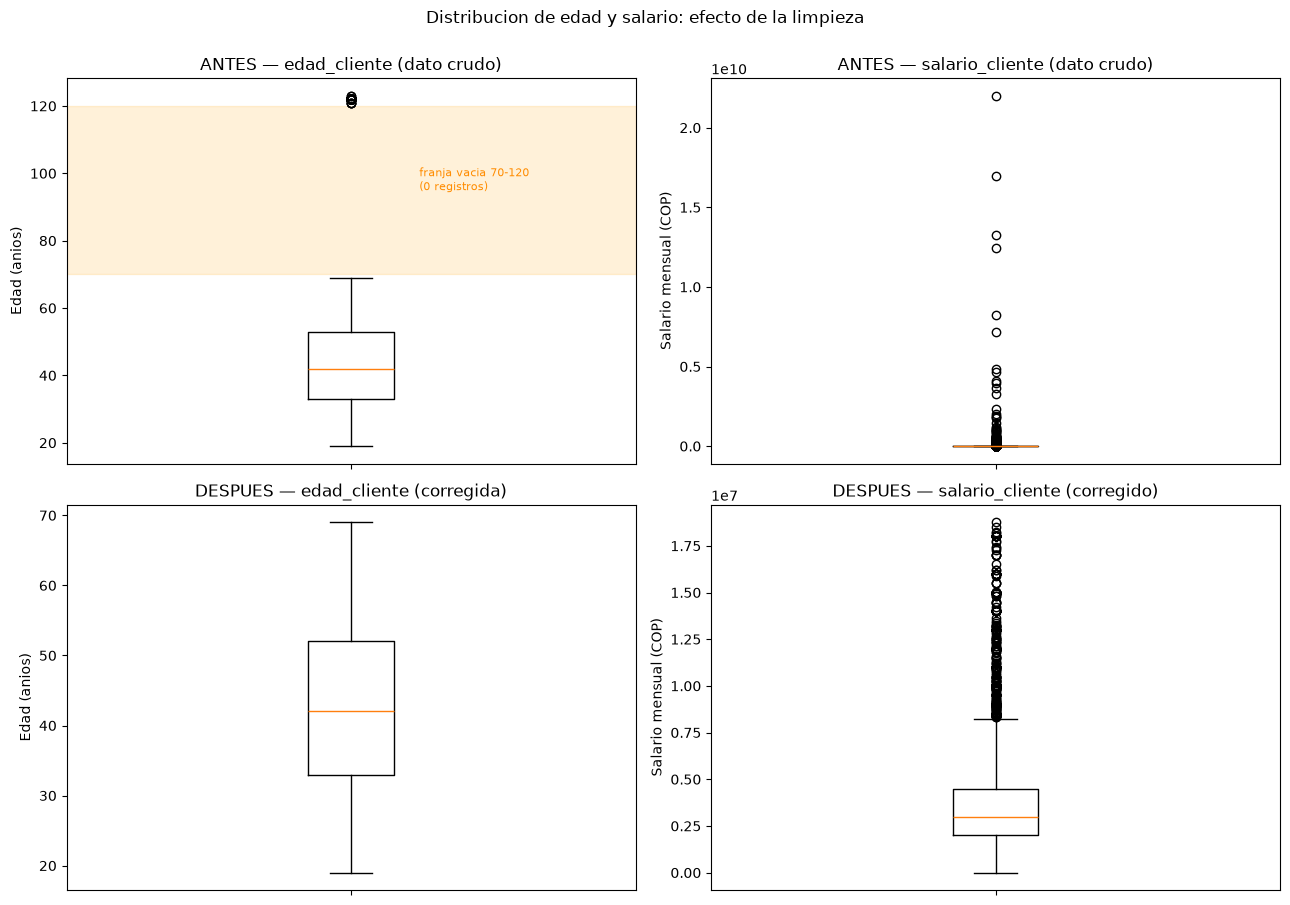

=== ANTES (dato crudo) ===
  edad    -> min 19, max 123, registros entre 70 y 120 anios: 0
  salario -> max 22,000,000,000 | P99 39,553,562 | P99.5 276,627,450 | registros > 50M: 97

=== DESPUES (corregido) ===
  edad    -> min 19, max 69, atipicos: 0
  salario -> min 1,000, max 18,756,573


In [18]:
# Boxplots de edad y salario: se grafica el estado ANTES y DESPUES de la limpieza.
# Motivo: la limpieza ocurre en la seccion 2, por lo que un boxplot unico sobre `df`
# ya no contiene los atipicos que justificaron esa limpieza. Mostrar ambos estados
# permite (a) ver la evidencia que motivo la correccion y (b) verificar su efecto.
import matplotlib.pyplot as plt

df_crudo_viz = pd.read_csv(RUTA_CRUDO, sep=';', encoding='utf-8-sig')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- Fila 1: ANTES de la limpieza (datos crudos) ---
axes[0, 0].boxplot(df_crudo_viz['edad_cliente'].dropna())
axes[0, 0].set_title('ANTES — edad_cliente (dato crudo)')
axes[0, 0].set_ylabel('Edad (anios)')
axes[0, 0].set_xticklabels([''])
axes[0, 0].axhspan(70, 120, color='orange', alpha=0.15)
axes[0, 0].annotate('franja vacia 70-120\n(0 registros)', xy=(1.12, 95), fontsize=8, color='darkorange')

axes[0, 1].boxplot(df_crudo_viz['salario_cliente'].dropna())
axes[0, 1].set_title('ANTES — salario_cliente (dato crudo)')
axes[0, 1].set_ylabel('Salario mensual (COP)')
axes[0, 1].set_xticklabels([''])

# --- Fila 2: DESPUES de la limpieza ---
axes[1, 0].boxplot(df['edad_cliente'].dropna())
axes[1, 0].set_title('DESPUES — edad_cliente (corregida)')
axes[1, 0].set_ylabel('Edad (anios)')
axes[1, 0].set_xticklabels([''])

axes[1, 1].boxplot(df['salario_cliente'].dropna())
axes[1, 1].set_title('DESPUES — salario_cliente (corregido)')
axes[1, 1].set_ylabel('Salario mensual (COP)')
axes[1, 1].set_xticklabels([''])

plt.suptitle('Distribucion de edad y salario: efecto de la limpieza', y=1.00)
plt.tight_layout()
plt.show()

# Cifras que sustentan la lectura de la figura
print("=== ANTES (dato crudo) ===")
print(f"  edad    -> min {df_crudo_viz['edad_cliente'].min()}, max {df_crudo_viz['edad_cliente'].max()}, "
      f"registros entre 70 y 120 anios: {((df_crudo_viz['edad_cliente'] > 69) & (df_crudo_viz['edad_cliente'] < 121)).sum()}")
print(f"  salario -> max {df_crudo_viz['salario_cliente'].max():,.0f} | P99 {df_crudo_viz['salario_cliente'].quantile(.99):,.0f} "
      f"| P99.5 {df_crudo_viz['salario_cliente'].quantile(.995):,.0f} | registros > 50M: {(df_crudo_viz['salario_cliente'] > 50_000_000).sum()}")
print("\n=== DESPUES (corregido) ===")
print(f"  edad    -> min {df['edad_cliente'].min()}, max {df['edad_cliente'].max()}, atipicos: 0")
print(f"  salario -> min {df['salario_cliente'].min():,.0f}, max {df['salario_cliente'].max():,.0f}")

#### Observaciones de los boxplots



**Fila superior  antes de la limpieza**

`edad_cliente`: la caja se sitúa entre los 33 y los 52 años con mediana en 42, y el bigote superior
llega hasta cerca de los 69. Por encima, separados por un espacio vacío considerable (marcado en
naranja), aparecen los puntos de 121 a 123 años. ese espacio vacío es la evidencia clave  entre
los 70 y los 120 años hay exactamente 0 registros por ende no existe transición gradual hacia esos
valores, lo que descarta que sean clientes mayores reales y apunta a un valor centinela o error de
captura.

`salario_cliente`: la caja aparece comprimida contra el eje inferior. La escala está dominada por
unos pocos registros que llegan hasta $22.000 millones mensuales, y el salto entre el percentil 99
($39,5M) y el 99,5 ($276,6M) confirma la magnitud del problema.  la transición es continua, razón por la
cual no se pudo fijar un umbral  y se recurrió al método IQR sobre escala logarítmica.

**Fila inferior  después de la limpieza**

`edad_cliente` queda contenida entre 19 y 69 años sin ningún punto atípico: los bigotes cierran
limpios. `salario_cliente` queda entre $1.000 y $18,76M, con una caja ahora legible y una cola
superior de valores altos pero plausibles, que se conservan por ser salarios posibles en el
mercado colombiano.

La limpieza no eliminó la
asimetría natural del salario que es una característica real de la variable y se tratará con
transformación logarítmica en la Fase 2 sino únicamente los valores imposibles.

## Resumen del tratamiento aplicado en la seccion2

| Variable | Problema detectado en el dato crudo | Tratamiento | Estado verificado |
|---|---|---|---|
| `edad_cliente` | 150 registros (1,39%) con 121–123 años, valor imposible, separados del resto por una franja vacía de 50 años | Imputación con la mediana (42) de los datos válidos | Rango final 19–69; 0 atípicos |
| `salario_cliente` | 97 registros por encima de $50M/mes, con máximo en $22.000 millones, más 24 registros en cero | IQR sobre escala logarítmica (límite $18,79M); 250 registros corregidos con la mediana ($3M) | Rango final $1.000–$18,76M |

**Ambos casos ya fueron tratados en la sección 2.** Las celdas de verificación anteriores
confirman el resultado: `Registros con edad > 90: 0` y `Registros con salario > 50.000.000: 0`.

El mínimo de salario tras la corrección es $1.000. No cumple ningún
criterio de corrección definido (no es cero, no supera el límite superior), pero tampoco es un
salario mensual creíble. Aplicar aquí un umbral basado en el salario mínimo legal colombiano
exigiría confirmar con el negocio si la variable admite ingresos parciales o no declarados. Se
deja documentado como regla de negocio pendiente de definir.

In [19]:
# Las variables analizadas se toman del DICCIONARIO DE DATOS, no de select_dtypes().
# Motivo: 'tipo_credito' y 'Pago_atiempo' son códigos categóricos almacenados como enteros;
# calcular su media, desviación o asimetría no tiene significado estadístico.
numericas = [c for c in VARS_NUMERICAS if c in df.columns]

print(f"Variables numéricas analizadas ({len(numericas)}): {numericas}")
print(f"\nExcluidas por ser categóricas (aunque su dtype sea entero): "
      f"{[c for c in VARS_CATEGORICAS if c in df.columns]}")

print("\n=== Describe() completo ===")
print(df[numericas].describe().T)

print("\n=== Medidas de TENDENCIA CENTRAL (incluida la moda) ===")
# La moda se calcula aparte porque describe() no la incluye. En variables continuas
# la moda puede no ser informativa, por lo que se acompana de su frecuencia: si la
# moda aparece pocas veces no representa un valor "tipico" sino una coincidencia.
tendencia_central = pd.DataFrame({
    'media': df[numericas].mean(),
    'mediana': df[numericas].median(),
    'moda': [df[c].mode().iloc[0] if not df[c].mode().empty else float('nan') for c in numericas],
    'frec_moda': [int((df[c] == df[c].mode().iloc[0]).sum()) if not df[c].mode().empty else 0
                  for c in numericas],
    'min': df[numericas].min(),
    'max': df[numericas].max(),
})
tendencia_central['%_moda'] = (tendencia_central['frec_moda'] / len(df) * 100).round(2)
print(tendencia_central.round(2).to_string())

print("\n=== Moda de las variables CATEGORICAS ===")
for col in [c for c in VARS_CATEGORICAS if c in df.columns]:
    m = df[col].mode().iloc[0]
    print(f"  {col:22s} -> moda = {m}  ({(df[col] == m).sum():,} registros, "
          f"{(df[col] == m).mean()*100:.2f}%)")

print("\n=== Medidas de dispersión avanzadas ===")
from scipy import stats
dispersion = pd.DataFrame({
    'rango': df[numericas].max() - df[numericas].min(),
    'IQR': df[numericas].quantile(0.75) - df[numericas].quantile(0.25),
    'Q1': df[numericas].quantile(0.25),
    'Q2_mediana': df[numericas].quantile(0.50),
    'Q3': df[numericas].quantile(0.75),
    'varianza': df[numericas].var(),
    'desv_estandar': df[numericas].std(),
    'skewness': df[numericas].apply(lambda x: stats.skew(x.dropna())),
    'kurtosis': df[numericas].apply(lambda x: stats.kurtosis(x.dropna())),
})
print(dispersion.round(3))

Variables numéricas analizadas (17): ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']

Excluidas por ser categóricas (aunque su dtype sea entero): ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'Pago_atiempo']

=== Describe() completo ===
                                 count          mean           std       min  \
capital_prestado               10763.0  2.434315e+06  1.909643e+06  360000.0   
plazo_meses                    10763.0  1.057558e+01  6.632082e+00       2.0   
edad_cliente                   10763.0  4.283388e+01  1.186417e+01      19.0   
salario_cliente                10763.0  3.650006e+06  2.546061e+06    1000.0   
total_otros_prestamos          10763

In [20]:
# Análisis univariado de variables CATEGÓRICAS: tablas de frecuencia
print("=== Tablas de frecuencia (variables categóricas) ===")
for col in [c for c in VARS_CATEGORICAS if c in df.columns]:
    frec = df[col].value_counts(dropna=False)
    frec_rel = df[col].value_counts(dropna=False, normalize=True).mul(100).round(2)
    tabla = pd.DataFrame({'frecuencia': frec, 'porcentaje_%': frec_rel})
    print(f"\n--- {col} ---")
    print(tabla)

=== Tablas de frecuencia (variables categóricas) ===

--- tipo_credito ---
              frecuencia  porcentaje_%
tipo_credito                          
4                   7747         71.98
9                   2876         26.72
10                   116          1.08
6                     21          0.20
7                      2          0.02
68                     1          0.01

--- tipo_laboral ---
               frecuencia  porcentaje_%
tipo_laboral                           
Empleado             6754         62.75
Independiente        4009         37.25

--- tendencia_ingresos ---
                    frecuencia  porcentaje_%
tendencia_ingresos                          
Creciente                 5335         49.57
Sin_dato                  2932         27.24
Decreciente               1301         12.09
Estable                   1195         11.10

--- Pago_atiempo ---
              frecuencia  porcentaje_%
Pago_atiempo                          
1                  10252         

In [21]:
# Tablas pivote: resumen de variables numéricas agregadas por categoría.
# Complementan las tablas de frecuencia en el análisis univariado.
print("=== Tabla pivote: estadísticos de capital y cuota por tipo de crédito ===")
pivote_credito = df.pivot_table(
    index='tipo_credito',
    values=['capital_prestado', 'cuota_pactada', 'plazo_meses'],
    aggfunc=['mean', 'median', 'count']
).round(0)
print(pivote_credito)

print("\n=== Tabla pivote: perfil del cliente por tipo laboral ===")
pivote_laboral = df.pivot_table(
    index='tipo_laboral',
    values=['edad_cliente', 'salario_cliente', 'cant_creditosvigentes'],
    aggfunc=['mean', 'median']
).round(0)
print(pivote_laboral)

=== Tabla pivote: estadísticos de capital y cuota por tipo de crédito ===
                         mean                                     median  \
             capital_prestado cuota_pactada plazo_meses capital_prestado   
tipo_credito                                                               
4                   2414644.0      235312.0        11.0        1929896.0   
6                   2860483.0      171862.0        18.0        2309860.0   
7                   8117212.0      276845.0        50.0        8117212.0   
9                   2445491.0      266929.0         8.0        1892546.0   
10                  3292477.0      234407.0        16.0        2328660.0   
68                  2822824.0       49007.0        48.0        2822824.0   

                                                  count                \
             cuota_pactada plazo_meses capital_prestado cuota_pactada   
tipo_credito                                                            
4                 1769

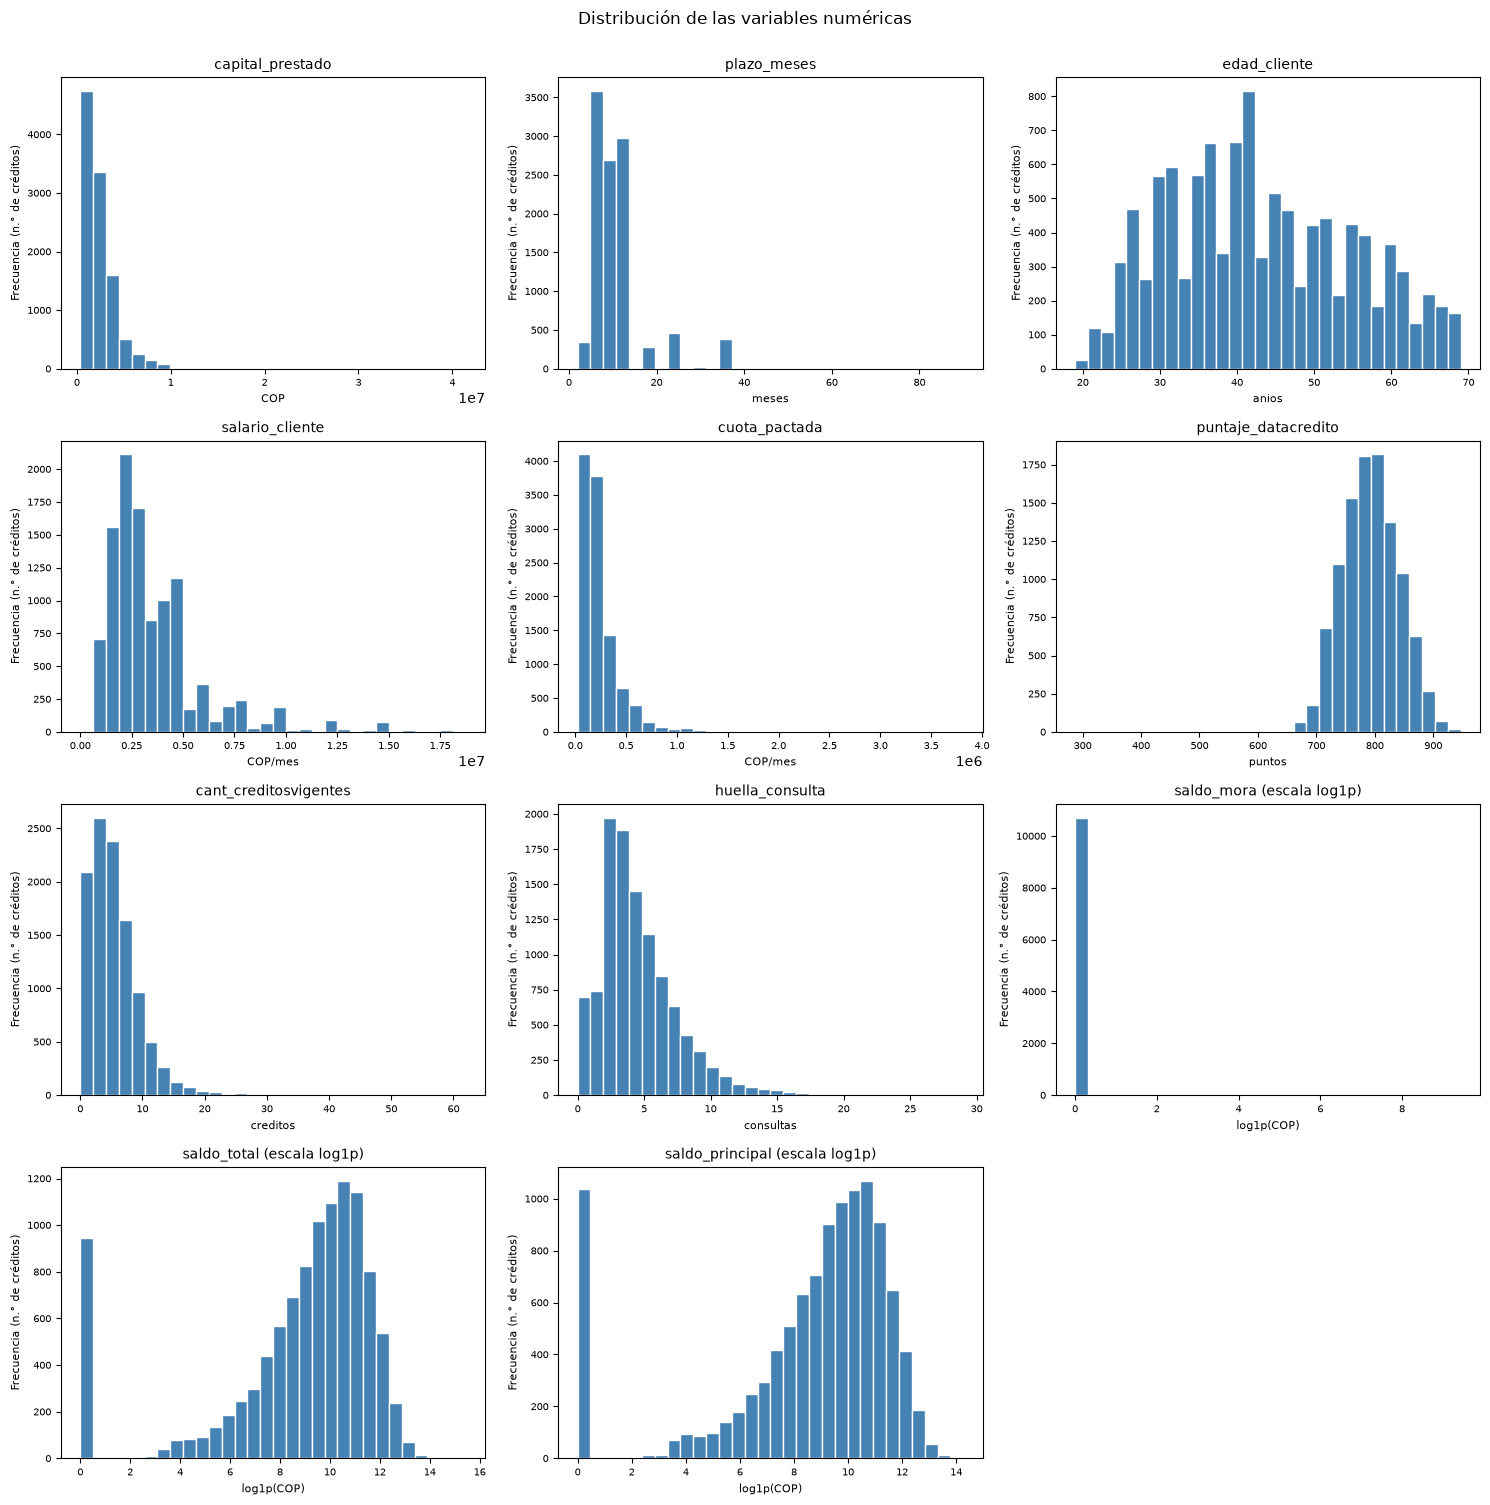

=== Concentración en cero (explica la forma de los histogramas de saldo) ===
  saldo_mora               ->  99.49% de los registros valen exactamente 0
  saldo_total              ->   8.78% de los registros valen exactamente 0
  saldo_principal          ->   9.64% de los registros valen exactamente 0
  saldo_mora_codeudor      ->  99.97% de los registros valen exactamente 0
  total_otros_prestamos    ->   4.13% de los registros valen exactamente 0


In [22]:
# Histogramas de variables numericas (forma de la distribucion).
# Las tres variables de saldo concentran mas del 85% de sus valores en cero: en escala
# original el histograma es una sola barra y no comunica nada. Para ellas se usa log1p,
# que comprime la cola y permite ver la distribucion de los valores distintos de cero.
import matplotlib.pyplot as plt

vars_hist = [
    ('capital_prestado', 'COP', False), ('plazo_meses', 'meses', False),
    ('edad_cliente', 'anios', False), ('salario_cliente', 'COP/mes', False),
    ('cuota_pactada', 'COP/mes', False), ('puntaje_datacredito', 'puntos', False),
    ('cant_creditosvigentes', 'creditos', False), ('huella_consulta', 'consultas', False),
    ('saldo_mora', 'log1p(COP)', True), ('saldo_total', 'log1p(COP)', True),
    ('saldo_principal', 'log1p(COP)', True),
]

fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()
for i, (col, unidad, usar_log) in enumerate(vars_hist):
    serie = df[col].dropna()
    if usar_log:
        serie = np.log1p(serie)
    axes[i].hist(serie, bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}' + (' (escala log1p)' if usar_log else ''), fontsize=10)
    axes[i].set_xlabel(unidad, fontsize=8)
    axes[i].set_ylabel('Frecuencia (n.° de créditos)', fontsize=8)
    axes[i].tick_params(labelsize=7)
for j in range(len(vars_hist), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distribución de las variables numéricas', y=1.00)
plt.tight_layout()
plt.show()

# Proporcion de ceros: dato que explica la forma de los histogramas de saldo
print("=== Concentración en cero (explica la forma de los histogramas de saldo) ===")
for col in ['saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor',
            'total_otros_prestamos']:
    print(f"  {col:24s} -> {(df[col] == 0).mean()*100:6.2f}% de los registros valen exactamente 0")

#### Analisis de los histogramas

**Variables monetarias (`capital_prestado`, `salario_cliente`, `cuota_pactada`)**
Las tres presentan la misma forma: una barra alta en los valores bajos y una cola que se extiende
hacia la derecha. En `capital_prestado`, la mediana es de $1.921.920 mientras la media sube a
$2.434.315 que la media supere a la mediana confirma que unos pocos créditos grandes arrastran
el promedio hacia arriba. Lo mismo ocurre en `salario_cliente` (mediana $3.000.000, media
$3.650.006) y en `cuota_pactada` (mediana $182.863, media $243.617).

Usar la media como "valor típico" en estas variables sería engañoso entonces debe usarse
la mediana.

**`plazo_meses`**
No es una distribución continua sino escalonada: se concentra en valores comerciales redondos.
Los plazos de 6 meses (3.326 créditos) y 12 meses (2.658) concentran por sí solos el 55,6% de la
cartera, seguidos de 10 meses (1.520). La entidad opera con plazos cortos: el percentil 90 está
en 18 meses.

**`edad_cliente`**
Es la única variable con forma cercana a una campana. Se concentra entre los 30 y los 55 años,
con mediana en 42. No presenta la cola larga de las variables monetarias, lo que coincide con su
asimetría casi nula (skewness 0,27).

**`puntaje_datacredito`**
Tras depurar los 153 valores inválidos, la distribución se concentra entre 700 y 900 puntos
(mediana 792). La barra dominante en la zona alta indica que la mayoría de los clientes
aprobados ya tenían buen score, lo cual es esperable: son créditos que la entidad efectivamente
desembolsó, no solicitudes.

**`cant_creditosvigentes` y `huella_consulta`**
Ambas son conteos con forma de cola descendente. La mediana de créditos vigentes es 5 y la de
consultas 4. El 3,8% de los clientes no tiene ningún crédito vigente y el 6,5% no registra
consultas recientes.

**Los tres saldos (`saldo_mora`, `saldo_total`, `saldo_principal`)** graficados en escala logp
En escala original estas tres variables producen una sola barra pegada al cero, sin información
visible por eso se grafican con `logp`, que comprime la cola y permite observar la distribución
de los valores distintos de cero. La celda imprime la proporción exacta de ceros de cada una.
El caso extremo es `saldo_mora`, donde la enorme mayoría de registros vale exactamente 0.

Estas variables el **monto** aporta poca información porque casi no varía lo
informativo es el **hecho binario** de tener o no tener saldo. Esa intuición se confirma
cuantitativamente en la sección 7 `tiene_mora_previa` (binaria) supera a `saldo_mora` (monto) como
predictor.

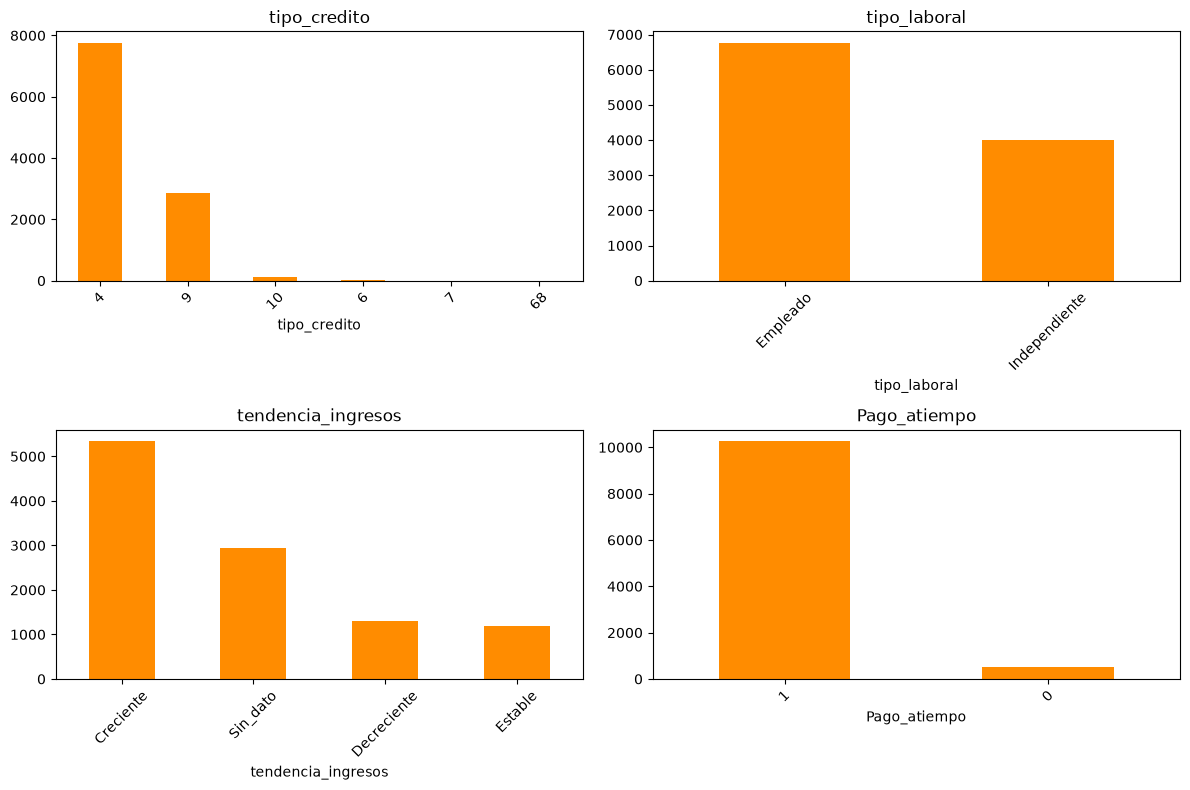


tipo_credito:
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

tipo_laboral:
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

tendencia_ingresos:
tendencia_ingresos
Creciente      5335
Sin_dato       2932
Decreciente    1301
Estable        1195
Name: count, dtype: int64

Pago_atiempo:
Pago_atiempo
1    10252
0      511
Name: count, dtype: int64


In [23]:
# Countplots de variables categóricas
vars_cat = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'Pago_atiempo']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(vars_cat):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='darkorange')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Verificación
for col in vars_cat:
    print(f"\n{col}:")
    print(df[col].value_counts())

#### Analisis de los countplots

**`tipo_credito`
Dos categorías acaparan casi toda la cartera: el tipo 4 con 7.747 créditos (71,98%) y el tipo 9
con 2.876 (26,72%). Juntos suman el 98,7%. Las demás categorías son marginales: tipo 10 con 116
registros (1,08%), tipo 6 con 21 (0,20%), tipo 7 con 2 y tipo 68 con 1 solo registro.
 cualquier conclusión sobre los tipos 6, 7 y 68 se apoya en muy
pocos casos y debe presentarse como indicio, no como resultado concluyente. es por eso que para la fase de
modelado convendrá agrupar las categorías minoritarias en una sola clase "Otros".

**`tipo_laboral`
6.754 empleados (62,75%) frente a 4.009 independientes (37,25%). Ambos grupos tienen tamaño
suficiente para comparar tasas de mora con confianza, a diferencia de lo que ocurre con
`tipo_credito`.

**`tendencia_ingreso
`Creciente` domina con 5.335 registros (49,57%), pero la segunda categoría más frecuente es
`Sin_dato` con 2.932 (27,24%). Es decir, más de una cuarta parte de la cartera no tiene esta
información. `Decreciente` (1.301) y `Estable` (1.195) quedan por debajo del 13% cada una.

Que `Sin_dato` sea tan frecuente obliga a tratarla como una categoría
con significado propio y no como un hueco a rellenar.

**`Pago_atiempo` Desbalance**
La diferencia visual entre las dos barras es la constatación gráfica del problema central del
proyecto: 10.252 créditos al día (95,25%) contra 511 en mora (4,75%). La barra de mora es tan
pequeña que apenas se aprecia junto a la otra.

### Tipo de distribución (3.1)

Con base en el `describe()`, las medidas de tendencia central y dispersión, y los histogramas.
**Todos los valores de esta tabla corresponden al dataset ya depurado** (después de la sección 2),
que es el que alimenta el EDA.

| Variable | Skewness | Kurtosis | Distribución observada |
|---|---|---|---|
| `edad_cliente` | 0,27 | −0,83 | Aproximadamente **simétrica / cuasi-gaussiana**; ligeramente sesgada a la derecha y algo más plana que una normal |
| `puntaje_datacredito` | **−0,71** | **5,25** | **Unimodal, moderadamente sesgada a la izquierda**, concentrada entre 700 y 900 puntos con una cola izquierda delgada de scores bajos |
| `salario_cliente` | 2,20 | 6,34 | **Sesgada a la derecha** (log-normal) |
| `plazo_meses` | 2,46 | 7,78 | **Sesgada a la derecha**, discreta y escalonada, concentrada en plazos comerciales cortos |
| `cant_creditosvigentes`, `huella_consulta` | 1,80 / 1,49 | 8,62 / 4,00 | Sesgadas a la derecha, tipo conteo (comportamiento Poisson) |
| `capital_prestado` | 3,72 | 35,3 | **Fuertemente sesgada a la derecha** (log-normal) |
| `cuota_pactada` | 3,79 | 26,6 | **Fuertemente sesgada a la derecha** |
| `saldo_principal` | 5,11 | 52,3 | **Extremadamente sesgada a la derecha** |
| `saldo_total`, `saldo_mora`, `saldo_mora_codeudor`, `total_otros_prestamos` | 20 a 98 | 797 a 9.813 | **Extremadamente sesgadas a la derecha**: la gran mayoría en 0 y unos pocos valores muy altos |

 `puntaje_datacredito`. Antes de la depuración, esta variable **sí** presentaba una
forma bimodal, con un grupo artificial de 145 registros en el valor 0 separado del cuerpo
principal. Ese grupo no eran scores bajos sino ausencia de score, y fue convertido a NaN en la
sección 2.4. Tras la corrección la distribución es unimodal (mínimo 287, máximo 947) y su
asimetría cae de un valor extremo a 0,71. La bimodalidad era un artefacto del dato sucio, no una
característica de la variable: es exactamente el tipo de conclusión errónea que la depuración
basada en el diccionario de datos evita.


- Ninguna variable monetaria es gaussiana: si se usan modelos que asumen normalidad o son
  sensibles a la escala, conviene transformación logarítmica o escalado robusto.
- La kurtosis extrema en los saldos indica presencia de valores atípicos legítimos del negocio
  financiero, no errores de captura.
- La moda de las variables monetarias coincide con valores comerciales redondos
  ($3.000.000 en salario, plazos de 6 y 12 meses), lo que confirma que se trata de datos
  declarados o pactados y no de mediciones continuas.

## 3.2 Análisis bivariado

In [24]:
# analisis vibariado variables vs pago_atiempo
# Comparación de variables numéricas clave entre clientes al día vs en mora
variables_clave = ['edad_cliente', 'salario_cliente', 'capital_prestado', 
                    'plazo_meses', 'cuota_pactada', 'cant_creditosvigentes', 
                    'huella_consulta', 'puntaje_datacredito']

comparacion = df.groupby('Pago_atiempo')[variables_clave].median()
print("Mediana por grupo (0 = mora, 1 = al día):")
print(comparacion)

Mediana por grupo (0 = mora, 1 = al día):
              edad_cliente  salario_cliente  capital_prestado  plazo_meses  \
Pago_atiempo                                                                 
0                     38.0        3000000.0         2268000.0         10.0   
1                     42.0        3000000.0         1908446.5         10.0   

              cuota_pactada  cant_creditosvigentes  huella_consulta  \
Pago_atiempo                                                          
0                  199002.0                    5.0              5.0   
1                  182576.0                    5.0              4.0   

              puntaje_datacredito  
Pago_atiempo                       
0                           769.0  
1                           792.0  


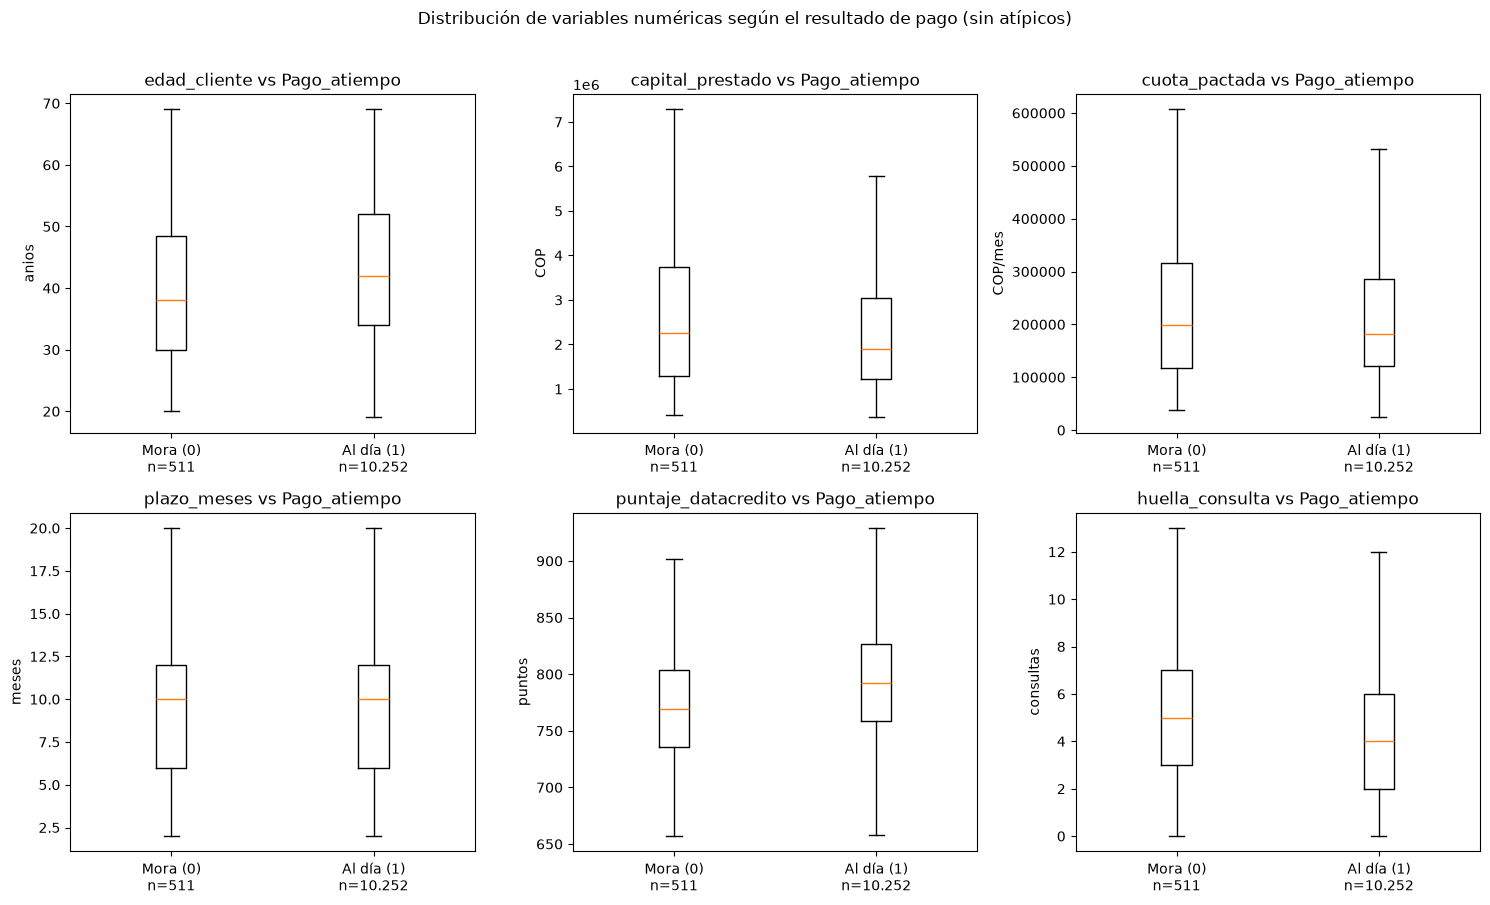

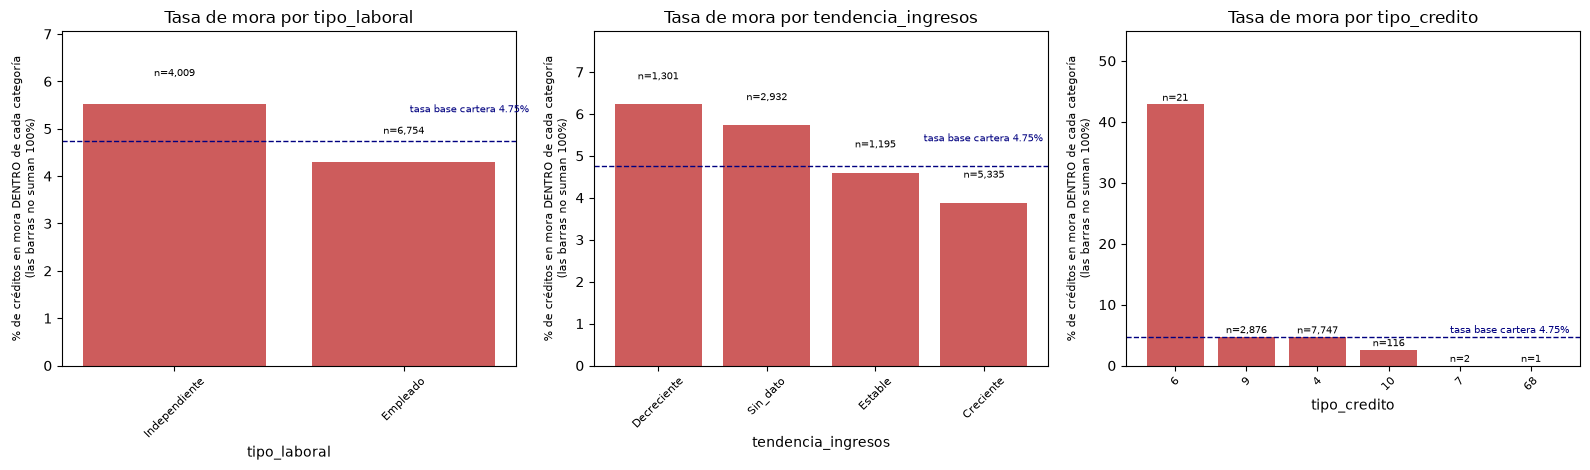

In [25]:
# Graficos bivariados: distribucion de variables clave segun la variable objetivo.
# Nota metodologica: se usa showfliers=False para que las cajas sean legibles, pero eso
# oculta las colas. Cuando la senal de una variable vive en la cola (caso de plazo_meses),
# el boxplot puede sugerir "sin diferencia" erroneamente; por eso la seccion 3.2.1
# complementa estos graficos con tasas de mora por tramo.
vars_biv = ['edad_cliente', 'capital_prestado', 'cuota_pactada', 'plazo_meses',
            'puntaje_datacredito', 'huella_consulta']
unidades = {'edad_cliente': 'anios', 'capital_prestado': 'COP', 'cuota_pactada': 'COP/mes',
            'plazo_meses': 'meses', 'puntaje_datacredito': 'puntos', 'huella_consulta': 'consultas'}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(vars_biv):
    datos = [df.loc[df['Pago_atiempo'] == 0, col].dropna(),
             df.loc[df['Pago_atiempo'] == 1, col].dropna()]
    axes[i].boxplot(datos, tick_labels=['Mora (0)\nn=511', 'Al día (1)\nn=10.252'],
                    showfliers=False)
    axes[i].set_title(f'{col} vs Pago_atiempo')
    axes[i].set_ylabel(unidades[col])
plt.suptitle('Distribución de variables numéricas según el resultado de pago (sin atípicos)', y=1.00)
plt.tight_layout()
plt.show()

# --- Tasa de mora por categoria: se anade el n de cada grupo y la tasa base ---
tasa_base = (1 - df['Pago_atiempo'].mean()) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, col in zip(axes, ['tipo_laboral', 'tendencia_ingresos', 'tipo_credito']):
    agg = df.groupby(col)['Pago_atiempo'].agg(['mean', 'count'])
    agg['tasa'] = (1 - agg['mean']) * 100
    agg = agg.sort_values('tasa', ascending=False)
    barras = ax.bar(agg.index.astype(str), agg['tasa'], color='indianred')
    # El n de cada grupo va sobre la barra: sin el, una barra de 21 registros
    # se lee visualmente igual de solida que una de 7.747.
    for b, (_, fila) in zip(barras, agg.iterrows()):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.6,
                f"n={int(fila['count']):,}", ha='center', fontsize=7.5)
    ax.axhline(tasa_base, color='navy', linestyle='--', linewidth=1)
    ax.text(len(agg) - 0.45, tasa_base + 0.6, f'tasa base cartera {tasa_base:.2f}%',
            fontsize=7.5, color='navy', ha='right')
    ax.set_title(f'Tasa de mora por {col}')
    ax.set_ylabel('% de créditos en mora DENTRO de cada categoría\n(las barras no suman 100%)',
                  fontsize=8)
    ax.set_xlabel(col)
    ax.set_ylim(0, max(agg['tasa']) * 1.28)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

#### Analisis de los gráficos bivariados

**Primer gráfico boxplots por grupo (mora vs. al día)**

Cada par de cajas compara la distribución de una variable entre los créditos que cayeron en mora
(izquierda) y los que se pagaron a tiempo (derecha). Las medianas observadas:

| Variable | En mora | Al día | Diferencia |
|---|---|---|---|
| `edad_cliente` | 38 años | 42 años | Los clientes en mora son 4 años más jóvenes |
| `capital_prestado` | $2.268.000 | $1.908.447 | Pidieron $359.554 más (19% más) |
| `cuota_pactada` | $199.002 | $182.576 | Cuota $16.426 más alta (9% más) |
| `puntaje_datacredito` | 769 | 792 | 23 puntos menos de score |
| `huella_consulta` | 5 consultas | 4 consultas | Una consulta más en la central de riesgo |
| `plazo_meses` | 10 meses | 10 meses | Medianas idénticas |

**Las cajas se superponen ampliamente en todos los casos.** Una superposición así significa que
existen muchos clientes al día con perfil similar al de los que cayeron en mora. Ninguna de estas
variables, por sí sola, permite trazar una línea de corte que separe los dos grupos.

>  `plazo_meses`Las medianas empatan en 10 meses y el
> boxplot dibujado sin atípicos para que las cajas sean legibles queda truncado alrededor de los
> 20 meses. Ambas cosas juntas sugieren "sin diferencia".

**Segundo gráfico tasas de mora por categoría**

Cada barra lleva su tamaño de muestra (`n=`) y la línea azul punteada marca la tasa base de la
cartera (4,75%), para poder juzgar de un vistazo si una categoría está por encima o por debajo del
promedio y con cuánto respaldo muestral.

- **`tipo_credito`**: la barra del tipo 6 (42,86%) se dispara respecto a las demás, que se mueven
  entre 2,59% y 4,73%. Es la diferencia más grande de todo el análisis, y el contraste estadístico
  la confirma (sección 3.2). Con solo 21 registros, sin embargo, el intervalo de confianza es muy
  ancho el efecto es real pero su magnitud es imprecisa.

- **`tendencia_ingresos`**: existe un orden coherente con el negocio. `Decreciente` presenta la
  mayor tasa (6,23%), seguida de `Sin_dato` (5,73%), luego `Estable` (4,60%) y por último
  `Creciente` (3,88%). Que los clientes con ingresos en descenso incumplan más que los de ingresos
  crecientes es consistente. el grupo `Sin_dato` se ubica en segundo
  lugar de riesgo, por encima de `Estable`.

- **`tipo_laboral`**: los independientes muestran 5,51% frente al 4,29% de los empleados. Es una
  diferencia modesta (1,22 puntos porcentuales) pero estadísticamente significativa por el tamaño
  de ambos grupos (chi-cuadrado, p = 0,0047).

Estas barras son **tasas de mora dentro de cada grupo**, no porciones de un
total. Por eso no suman 100%: cada barra responde a la pregunta "de los clientes de esta categoría,
¿qué porcentaje cayó en mora?", y cada categoría se calcula por separado. El eje Y lo indica
explícitamente.

In [26]:
# tasa de morosidad por segmento categorico
tasa_laboral = df.groupby('tipo_laboral')['Pago_atiempo'].agg(['mean', 'count'])
tasa_laboral['tasa_mora_%'] = ((1 - tasa_laboral['mean']) * 100).round(2)
print(tasa_laboral[['count', 'tasa_mora_%']])

# Tasa de mora por tipo de crédito
tasa_credito = df.groupby('tipo_credito')['Pago_atiempo'].agg(['mean', 'count'])
tasa_credito['tasa_mora_%'] = ((1 - tasa_credito['mean']) * 100).round(2)
print(tasa_credito[['count', 'tasa_mora_%']].sort_values('tasa_mora_%', ascending=False))

               count  tasa_mora_%
tipo_laboral                     
Empleado        6754         4.29
Independiente   4009         5.51
              count  tasa_mora_%
tipo_credito                    
6                21        42.86
9              2876         4.73
4              7747         4.69
10              116         2.59
7                 2         0.00
68                1         0.00


In [27]:
# Bivariado CATEGÓRICA vs CATEGÓRICA: tablas de contingencia y prueba chi-cuadrado.
# Es la prueba estadísticamente correcta para 'tipo_credito' vs la variable objetivo
# (la correlación de Pearson NO aplica sobre variables nominales).
from scipy.stats import chi2_contingency

print("=== Prueba chi-cuadrado de independencia frente a la variable objetivo ===\n")
for col in [c for c in VARS_CATEGORICAS if c in df.columns and c != TARGET]:
    tabla = pd.crosstab(df[col], df[TARGET])
    chi2, p, gl, _ = chi2_contingency(tabla)
    # V de Cramér: tamaño del efecto para variables nominales
    n = tabla.values.sum()
    v_cramer = (chi2 / (n * (min(tabla.shape) - 1))) ** 0.5
    signif = "SÍ" if p < 0.05 else "no"
    print(f"{col}:")
    print(f"   chi2 = {chi2:.2f} | gl = {gl} | p-valor = {p:.4g} | V de Cramér = {v_cramer:.4f}")
    print(f"   ¿Asociación estadísticamente significativa (alfa=0.05)? {signif}\n")

print("=== Tabla de contingencia: tipo_credito vs Pago_atiempo ===")
cont = pd.crosstab(df['tipo_credito'], df[TARGET], margins=True, margins_name='Total')
cont.columns = ['Mora (0)', 'Al día (1)', 'Total']
cont['tasa_mora_%'] = (cont['Mora (0)'] / cont['Total'] * 100).round(2)
print(cont)

=== Prueba chi-cuadrado de independencia frente a la variable objetivo ===

tipo_credito:
   chi2 = 68.86 | gl = 5 | p-valor = 1.772e-13 | V de Cramér = 0.0800
   ¿Asociación estadísticamente significativa (alfa=0.05)? SÍ

tipo_laboral:
   chi2 = 8.00 | gl = 1 | p-valor = 0.004686 | V de Cramér = 0.0273
   ¿Asociación estadísticamente significativa (alfa=0.05)? SÍ

tendencia_ingresos:
   chi2 = 21.48 | gl = 3 | p-valor = 8.375e-05 | V de Cramér = 0.0447
   ¿Asociación estadísticamente significativa (alfa=0.05)? SÍ

=== Tabla de contingencia: tipo_credito vs Pago_atiempo ===
              Mora (0)  Al día (1)  Total  tasa_mora_%
tipo_credito                                          
4                  363        7384   7747         4.69
6                    9          12     21        42.86
7                    0           2      2         0.00
9                  136        2740   2876         4.73
10                   3         113    116         2.59
68                   0           1

`tipo_credito` es una variable nominal. Aplicarle
correlación de Pearson produce r = 0.001, un valor que sugiere ausencia total de relación con la
mora. La prueba chi-cuadrado, que sí es apropiada para variables nominales, revela lo contrario:
existe asociación estadísticamente significativa. La tasa de mora va de 2.59% (tipo 10) a 42.86%
(tipo 6).


## Analisis Segmentación categórica

- **`tipo_laboral`**: los independientes presentan una tasa de mora mayor que los empleados
  (5,51% vs 4,29%), consistente con la mayor variabilidad de ingresos de ese segmento. La V de
  Cramér es 0,027: asociación significativa pero de efecto pequeño.
- **`tipo_credito`**: el tipo 6 muestra una tasa de mora del **42,86%** (9 de 21 créditos), muy por
  encima del resto (2,59% a 4,73%). La prueba chi-cuadrado confirma que la asociación entre tipo de
  crédito y resultado de pago es significativa (p = 1,8e-13). Con 21 registros la magnitud exacta
  no es estimable con precisión, pero el efecto existe y amerita investigación prioritaria con el
  área de producto, sobre todo porque el significado del código 6 no está confirmado.
- **Tipos 7 y 68**: muestran 0% de mora, pero con 2 y 1 registro respectivamente. No son
  representativos y se excluyen de cualquier conclusión.
- **`tendencia_ingresos`**: asociación significativa (p = 8,4e-05) con orden coherente con el
  negocio.

### 3.2.1 Tasa de mora por tramos

Comparar medianas entre dos grupos y calcular la correlación de Pearson son medidas de relación
lineal y central Con una variable objetivo binaria y muy desbalanceada (4,75% de mora), ambas
subestiman de forma sistemática la capacidad de una variable para discriminar riesgo, porque el
efecto suele concentrarse en los extremos de la distribución y no en el centro.

Esta sección aplica la técnica estándar en riesgo crediticio: **segmentar la variable en tramos y
medir la tasa de mora de cada tramo**. Es el mismo razonamiento que ya se aplicó a `tipo_credito`
en la sección anterior, donde la correlación de Pearson daba r = 0,001 y ocultaba un rango de
2,6% a 42,9%.

Se analizan dos variables donde este problema se hace evidente.

=== Tasa de mora por tramo de plazo_meses ===
             n_creditos  tasa_mora_%
plazo_meses                         
(0, 6]             3905         4.76
(6, 12]            5700         3.91
(12, 18]            275         4.36
(18, 24]            478         8.16
(24, 36]            403        12.66
(36, 90]              2         0.00
    (tasa base de la cartera: 4.75%)

=== Tasa de mora por banda de puntaje_datacredito ===
                     n_creditos  tasa_mora_%
puntaje_datacredito                         
(280, 600]                   25        64.00
(600, 700]                  207         9.18
(700, 750]                 1937         7.74
(750, 800]                 3895         4.49
(800, 850]                 3239         3.18
(850, 950]                 1307         2.91
    (tasa base de la cartera: 4.75%)

    Sin score valido (NaN): n=153, tasa de mora=6.54%


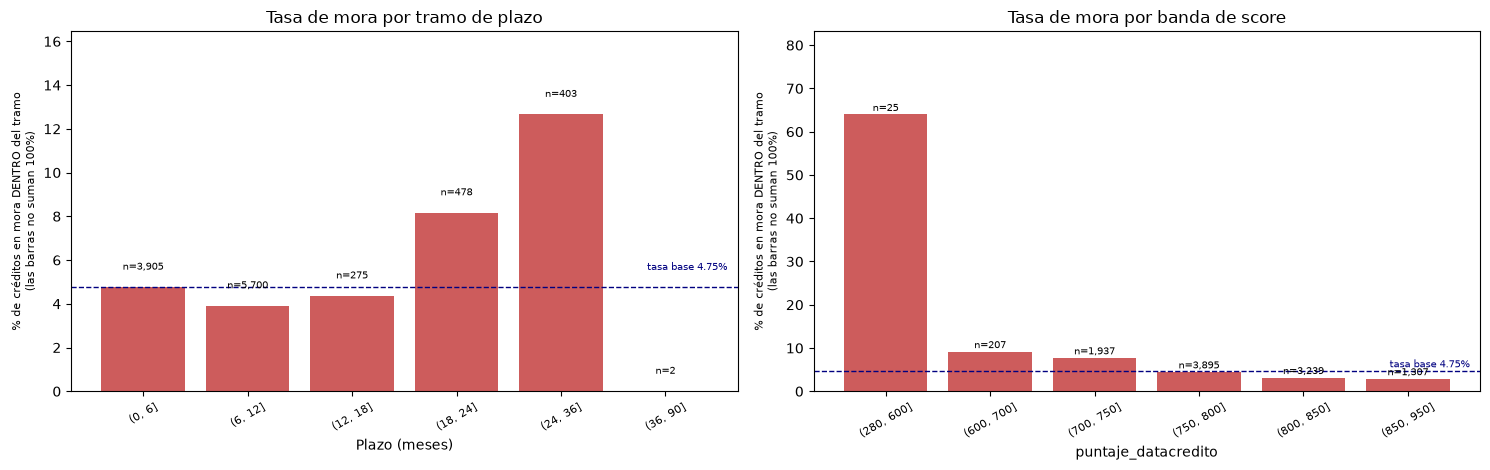

In [28]:
# Tasa de mora por tramos. Cada fila muestra la tasa DENTRO del tramo, no una
# porcion del total: las columnas de tasa no suman 100%.

def tasa_por_tramo(serie, etiqueta, cortes=None, cuantiles=None, datos=None):
    """Calcula tasa de mora por tramo. Devuelve la tabla y la imprime."""
    datos = df if datos is None else datos
    if cortes is not None:
        tramos = pd.cut(serie, cortes)
    else:
        tramos = pd.qcut(serie, cuantiles, duplicates='drop')
    tabla = datos.groupby(tramos, observed=True)['Pago_atiempo'].agg(['count', 'mean'])
    tabla['tasa_mora_%'] = ((1 - tabla['mean']) * 100).round(2)
    tabla = tabla[['count', 'tasa_mora_%']].rename(columns={'count': 'n_creditos'})
    print(f"=== {etiqueta} ===")
    print(tabla.to_string())
    print(f"    (tasa base de la cartera: {(1 - datos['Pago_atiempo'].mean())*100:.2f}%)\n")
    return tabla


# --- A) plazo_meses: el boxplot sugeria "sin diferencia" (medianas 10 vs 10) ---
t_plazo = tasa_por_tramo(df['plazo_meses'], 'Tasa de mora por tramo de plazo_meses',
                         cortes=[0, 6, 12, 18, 24, 36, 90])

# --- B) puntaje_datacredito: Pearson daba |r|=0.12 ("correlacion debil") ---
t_score = tasa_por_tramo(df['puntaje_datacredito'],
                         'Tasa de mora por banda de puntaje_datacredito',
                         cortes=[280, 600, 700, 750, 800, 850, 950])
sin_score = df['puntaje_datacredito'].isna()
print(f"    Sin score valido (NaN): n={sin_score.sum()}, "
      f"tasa de mora={(1 - df.loc[sin_score, 'Pago_atiempo'].mean())*100:.2f}%")

# --- Visualizacion de ambos gradientes ---
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
tasa_base = (1 - df['Pago_atiempo'].mean()) * 100
for ax, (tabla, titulo, xlab) in zip(axes, [
        (t_plazo, 'Tasa de mora por tramo de plazo', 'Plazo (meses)'),
        (t_score, 'Tasa de mora por banda de score', 'puntaje_datacredito')]):
    barras = ax.bar([str(i) for i in tabla.index], tabla['tasa_mora_%'], color='indianred')
    for b, n in zip(barras, tabla['n_creditos']):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.8, f'n={int(n):,}',
                ha='center', fontsize=7.5)
    ax.axhline(tasa_base, color='navy', linestyle='--', linewidth=1)
    ax.text(len(tabla) - 0.4, tasa_base + 0.8, f'tasa base {tasa_base:.2f}%',
            fontsize=7.5, color='navy', ha='right')
    ax.set_title(titulo)
    ax.set_xlabel(xlab)
    ax.set_ylabel('% de créditos en mora DENTRO del tramo\n(las barras no suman 100%)', fontsize=8)
    ax.set_ylim(0, max(tabla['tasa_mora_%']) * 1.30)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
plt.tight_layout()
plt.show()

#### Analisis tasa de mora por tramos

**`plazo_meses` sí discrimina riesgo, y el boxplot lo ocultaba.**
La tasa de mora es de 3,91% en los créditos de 6 a 12 meses y sube hasta **12,66% en los de 24 a
36 meses**: un gradiente de aproximadamente **3,2 veces**. Las medianas de ambos grupos empataban
en 10 meses porque el 89% de la cartera se concentra en plazos de 12 meses o menos la señal está
en un 8% de créditos largos que el boxplot recortó. El tramo de 36 a 90 meses tiene solo 2
registros y no permite conclusión.

A mayor plazo, más tiempo de exposición y más oportunidades de que cambie la
situación del cliente. Es una relación esperable que el análisis inicial había descartado por error.

en la fase 2 :`plazo_meses` debe entrar al modelo **por tramos**, no como número
continuo, porque la relación no es lineal (el tramo de 0–6 meses tiene más mora que el de 6–12).

**`puntaje_datacredito` es mucho más fuerte de lo que sugiere su correlación.**
El gradiente por banda es monótono y muy pronunciado: **64,00% de mora por debajo de 600 puntos
frente a 2,91% por encima de 850**. Son 22 veces de diferencia entre extremos. Esa misma variable
tiene un coeficiente de Pearson de apenas 0,1212, un valor que en una escala de 0 a 1 se lee como
"relación muy débil".

**Conclusion igual en los casos** con un target binario al 4,75%, la
correlación de Pearson y la comparación de medianas **no son medidas adecuadas del poder
discriminante**. Miden relación lineal promedio, no separación entre clases. Todas las
afirmaciones del tipo "ninguna variable supera |r| = 0,13, por lo tanto ninguna se relaciona con
la mora" 


### 3.2.2 Comportamiento temporal de la variable objetivo

El dataset cubre desembolsos entre noviembre de 2024 y abril de 2026. Ninguna sección anterior ha
verificado si el resultado de pago se comporta igual a lo largo de ese periodo, y es una
comprobación necesaria por dos razones:

1. **Si la tasa de mora varía según el mes de desembolso**, el momento del crédito es información
   relevante y un split aleatorio train/test podría mezclar periodos con comportamientos distintos.
2. **Si hay créditos cuyo plazo aún no ha vencido**, su etiqueta `Pago_atiempo` puede no estar
   definitivamente determinada: un crédito reciente todavía no ha tenido oportunidad de caer en
   mora. Esto afecta directamente al significado de la variable objetivo.

=== Tasa de mora segun el mes de desembolso ===
                   n_creditos  tasa_mora_%
anio_mes_prestamo                         
2024-11                   186         6.99
2024-12                  1216         6.09
2025-01                  1917         4.49
2025-02                  1094         5.85
2025-03                  1115         5.11
2025-04                  1102         6.26
2025-05                  1083         4.34
2025-06                   665         3.76
2025-07                   644         3.11
2025-08                   555         3.60
2025-09                   361         1.94
2025-10                   231         1.73
2025-11                   166         4.22
2025-12                   174         1.72
2026-01                   127         5.51
2026-02                    76         6.58
2026-03                    40         5.00
2026-04                    11         9.09

=== Madurez del credito (corte de observacion: 2026-04-26) ===
Creditos cuyo plazo pactado 

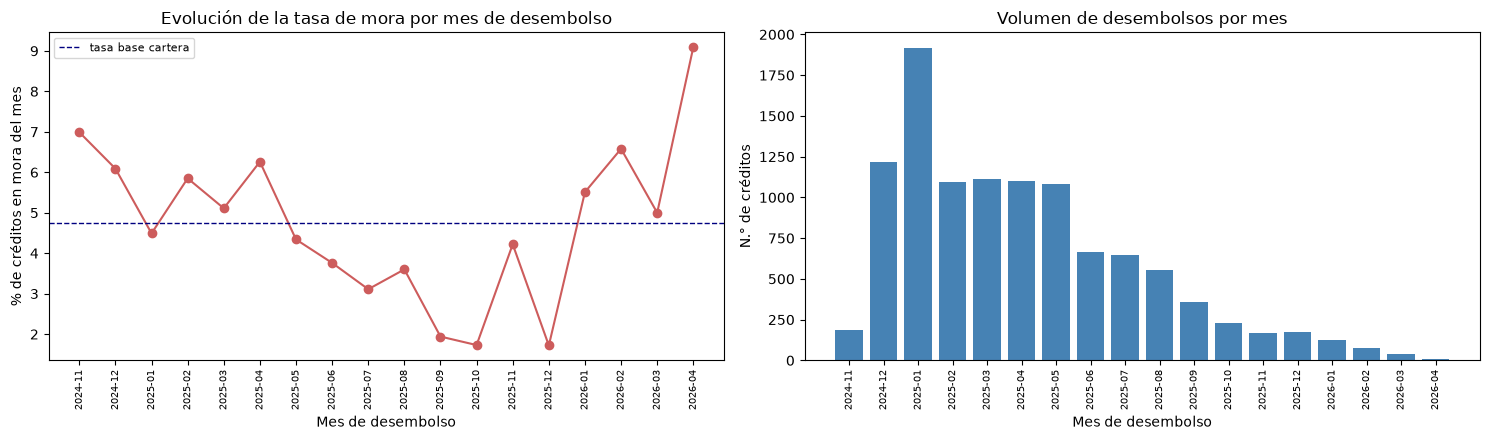

In [29]:
# Comportamiento del target a lo largo del tiempo.
df['anio_mes_prestamo'] = df['fecha_prestamo'].dt.to_period('M')

evolucion = df.groupby('anio_mes_prestamo')['Pago_atiempo'].agg(['count', 'mean'])
evolucion['tasa_mora_%'] = ((1 - evolucion['mean']) * 100).round(2)
print("=== Tasa de mora segun el mes de desembolso ===")
print(evolucion[['count', 'tasa_mora_%']].rename(columns={'count': 'n_creditos'}).to_string())

# Madurez del credito: vencimiento teorico = fecha de desembolso + plazo pactado
df['vencimiento_teorico'] = df['fecha_prestamo'] + pd.to_timedelta(df['plazo_meses'] * 30, unit='D')
ultima_fecha = df['fecha_prestamo'].max()
df['madurez_incompleta'] = df['vencimiento_teorico'] > ultima_fecha

print(f"\n=== Madurez del credito (corte de observacion: {ultima_fecha.date()}) ===")
print(f"Creditos cuyo plazo pactado vence DESPUES del corte: {df['madurez_incompleta'].sum():,} "
      f"({df['madurez_incompleta'].mean()*100:.1f}% de la cartera)")
_ = contraste_tasas("madurez_incompleta == True", df['madurez_incompleta'])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
ax = axes[0]
ax.plot(range(len(evolucion)), evolucion['tasa_mora_%'], marker='o', color='indianred')
ax.axhline((1 - df['Pago_atiempo'].mean())*100, color='navy', linestyle='--', linewidth=1,
           label='tasa base cartera')
ax.set_xticks(range(len(evolucion)))
ax.set_xticklabels([str(p) for p in evolucion.index], rotation=90, fontsize=7)
ax.set_title('Evolución de la tasa de mora por mes de desembolso')
ax.set_xlabel('Mes de desembolso')
ax.set_ylabel('% de créditos en mora del mes')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar([str(p) for p in evolucion.index], evolucion['count'], color='steelblue')
ax.set_xticks(range(len(evolucion)))
ax.set_xticklabels([str(p) for p in evolucion.index], rotation=90, fontsize=7)
ax.set_title('Volumen de desembolsos por mes')
ax.set_xlabel('Mes de desembolso')
ax.set_ylabel('N.° de créditos')
plt.tight_layout()
plt.show()

#### Analisis Comportamiento Temporal

**1. La tasa de mora no es estable en el tiempo.** Va desde un mínimo cercano al 1,7% en algunos
meses de finales de 2025 hasta valores por encima del 6-7% en los meses iniciales del periodo. Es
un rango de aproximadamente 4 veces entre los extremos. La correlación de Pearson de
`mes_prestamo` con el target es 0,0088 prácticamente cero  y de nuevo esa cifra oculta una
variación que sí existe.

** El volumen de desembolsos cae fuertemente hacia el final del periodo.** Los últimos meses
tienen entre 11 y 174 créditos frente a más de 1.000 en los meses centrales, por lo que sus tasas
son inestables y no deben interpretarse como tendencia.

**Aproximadamente el 20% de la cartera tiene madurez incompleta.** Son créditos cuyo plazo
pactado vence después de la última fecha registrada en el dataset. Para ellos, el valor de
`Pago_atiempo` refleja el estado observado hasta el corte, no el desenlace final del crédito.

**Por qué esto importa para las fases siguientes:**

- las variables temporales derivadas (`mes_prestamo`,
  `trimestre_prestamo`) tienen justificación para conservarse pese a su correlación casi nula. La
  antigüedad del crédito respecto a la fecha de corte también es candidata a variable derivada.


Una limitacion es que no se dispone de la fecha en que se determinó el resultado de pago, solo
de la fecha de desembolso. Por eso la madurez se estima aproximando cada mes a 30 dias.
cómo y cuándo se asigna `Pago_atiempo` es un requisito previo al modelado.

### 3.2.3 ¿La ausencia de dato es informativa? Análisis de las banderas de trazabilidad

Durante la limpieza (sección 2) se crearon columnas booleanas que registran qué filas fueron
intervenidas y cuáles tenían el dato ausente. Hasta aquí solo han servido como auditoría. Esta
sección las cruza con la variable objetivo para responder una pregunta de negocio concreta:
**¿los clientes sobre los que falta información incumplen más que los demás?**

Si la respuesta es afirmativa, la propia ausencia del
dato se convierte en un predictor y esas banderas pasan de ser metadatos a ser variables
candidatas para la Fase 2.

In [30]:
# Cruce de las banderas de trazabilidad contra la variable objetivo.
# Cada bandera se somete al mismo contraste estadistico usado en la seccion 2.4.
banderas = ['promedio_ingresos_datacredito_era_nulo', 'saldo_principal_era_nulo',
            'saldo_mora_codeudor_era_nulo', 'edad_cliente_corregida',
            'salario_cliente_corregido', 'tendencia_ingresos_reconstruida',
            'sin_historial_crediticio']

print("=== ¿La ausencia o correccion del dato predice la mora? ===\n")
resultados_banderas = []
for bandera in banderas:
    if bandera not in df.columns:
        continue
    mask = df[bandera].astype(bool)
    if mask.sum() == 0:
        continue
    resultados_banderas.append(contraste_tasas(bandera, mask))

resumen_banderas = pd.DataFrame(resultados_banderas)
resumen_banderas['significativo'] = resumen_banderas['p_valor'] < 0.05
print("=== Resumen ordenado por evidencia ===")
print(resumen_banderas[['grupo', 'n', 'tasa', 'tasa_resto', 'odds_ratio', 'p_valor',
                        'significativo']]
      .sort_values('p_valor').round(4).to_string(index=False))

=== ¿La ausencia o correccion del dato predice la mora? ===

promedio_ingresos_datacredito_era_nulo
   Grupo : n= 2,930  mora= 168  tasa=  5.73%   IC95% Wilson = [4.95% , 6.64%]
   Resto : n= 7,833  tasa=  4.38%
   Odds Ratio =   1.33 | p (Fisher exacto) = 0.0037  ->  SIGNIFICATIVO (p<0.05)

saldo_principal_era_nulo
   Grupo : n=   405  mora=  29  tasa=  7.16%   IC95% Wilson = [5.03% , 10.09%]
   Resto : n=10,358  tasa=  4.65%
   Odds Ratio =   1.58 | p (Fisher exacto) = 0.0308  ->  SIGNIFICATIVO (p<0.05)

saldo_mora_codeudor_era_nulo
   Grupo : n=   590  mora=  40  tasa=  6.78%   IC95% Wilson = [5.02% , 9.10%]
   Resto : n=10,173  tasa=  4.63%
   Odds Ratio =   1.50 | p (Fisher exacto) = 0.0216  ->  SIGNIFICATIVO (p<0.05)

edad_cliente_corregida
   Grupo : n=   150  mora=  11  tasa=  7.33%   IC95% Wilson = [4.14% , 12.65%]
   Resto : n=10,613  tasa=  4.71%
   Odds Ratio =   1.60 | p (Fisher exacto) = 0.1701  ->  NO SIGNIFICATIVO (p>=0.05)

salario_cliente_corregido
   Grupo : n=   250

#### Analisis banderas de trazabilidad

**Tres banderas resultan predictores estadísticamente significativos:**

| Bandera | n | Tasa de mora | Tasa del resto | Odds Ratio | p-valor |
|---|---|---|---|---|---|
| `promedio_ingresos_datacredito_era_nulo` | 2.930 | 5,73% | 4,38% | 1,33 | **0,0037** |
| `saldo_mora_codeudor_era_nulo` | 590 | 6,78% | 4,63% | 1,50 | **0,0216** |
| `saldo_principal_era_nulo` | 405 | 7,16% | 4,65% | 1,58 | **0,0308** |

**los **2.930 clientes sobre los que la central de riesgo no reporta
ingresos** incumplen más que aquellos con el dato disponible. La diferencia es moderada (1,35
puntos porcentuales) pero se apoya en el 27% de la cartera, lo que la hace estable: su intervalo de
confianza [4,95% , 6,64%] no contiene la tasa del grupo de comparación.

Que la central de riesgo no tenga información de ingresos de un
cliente sugiere una vinculación más débil o más reciente con el sistema financiero formal. La
ausencia del dato no es aleatoria: describe un perfil.

la bandera debe conservarse como variable del modelo. Si en
algún momento se decide imputar `promedio_ingresos_datacredito`, **la bandera debe conservarse
igualmente**, porque la información predictiva no está solo en el valor sino en el hecho de que
faltaba. Esto confirma que la decisión de la sección 2.2 de no imputar esa variable fue acertada.

**Las otras dos banderas significativas apuntan al mismo perfil.**
`saldo_principal_era_nulo` y `saldo_mora_codeudor_era_nulo` marcan clientes sin otros créditos
registrados y sin codeudor. Ambas señalan clientes con menor huella en el sistema financiero, la
misma dirección que la bandera anterior. Al describir poblaciones parcialmente solapadas, en la
Fase 2 conviene evaluarlas conjuntamente y no asumir que sus efectos se suman.

**Tres banderas no alcanzan significancia y se registran como hipótesis:**
`edad_cliente_corregida` (150 registros, 7,33% vs 4,71%, p = 0,17), `salario_cliente_corregido`
(250 registros, 6,00% vs 4,72%, p = 0,36) y `sin_historial_crediticio` (153 registros, 6,54% vs
4,72%, p = 0,33). Las tres apuntan en la dirección esperada pero sus intervalos de confianza
contienen la tasa base. Se conservan en el dataset por su valor de auditoría, no como predictores
validados.

 `tendencia_ingresos_reconstruida`.** Los 58 registros reconstruidos presentan 0% de
mora. Con esa muestra el intervalo de Wilson llega hasta 6,21%, así que es perfectamente compatible
con el azar (p = 0,12). sí una comprobación útil confirma que la
reconstrucción por signo no introdujo un sesgo evidente en la variable objetivo.

 Este es el mismo tipo de pregunta que allí se planteó sobre
`sin_historial_crediticio`. El principio de negocio "la ausencia de información es
informativa" la evidencia está en las banderas de
ausencia de reporte del buró, con muestras entre 405 y 2.930 registros, y no en el grupo de 153
clientes sin score.

> Posible fuga de información.** `saldo_principal_era_nulo` y
> `saldo_mora_codeudor_era_nulo` derivan de variables de saldo.  igual que con `saldo_mora`, que ese estado se registra **antes** del desembolso y no
> se actualiza después.

## 3.3 Análisis multivariado

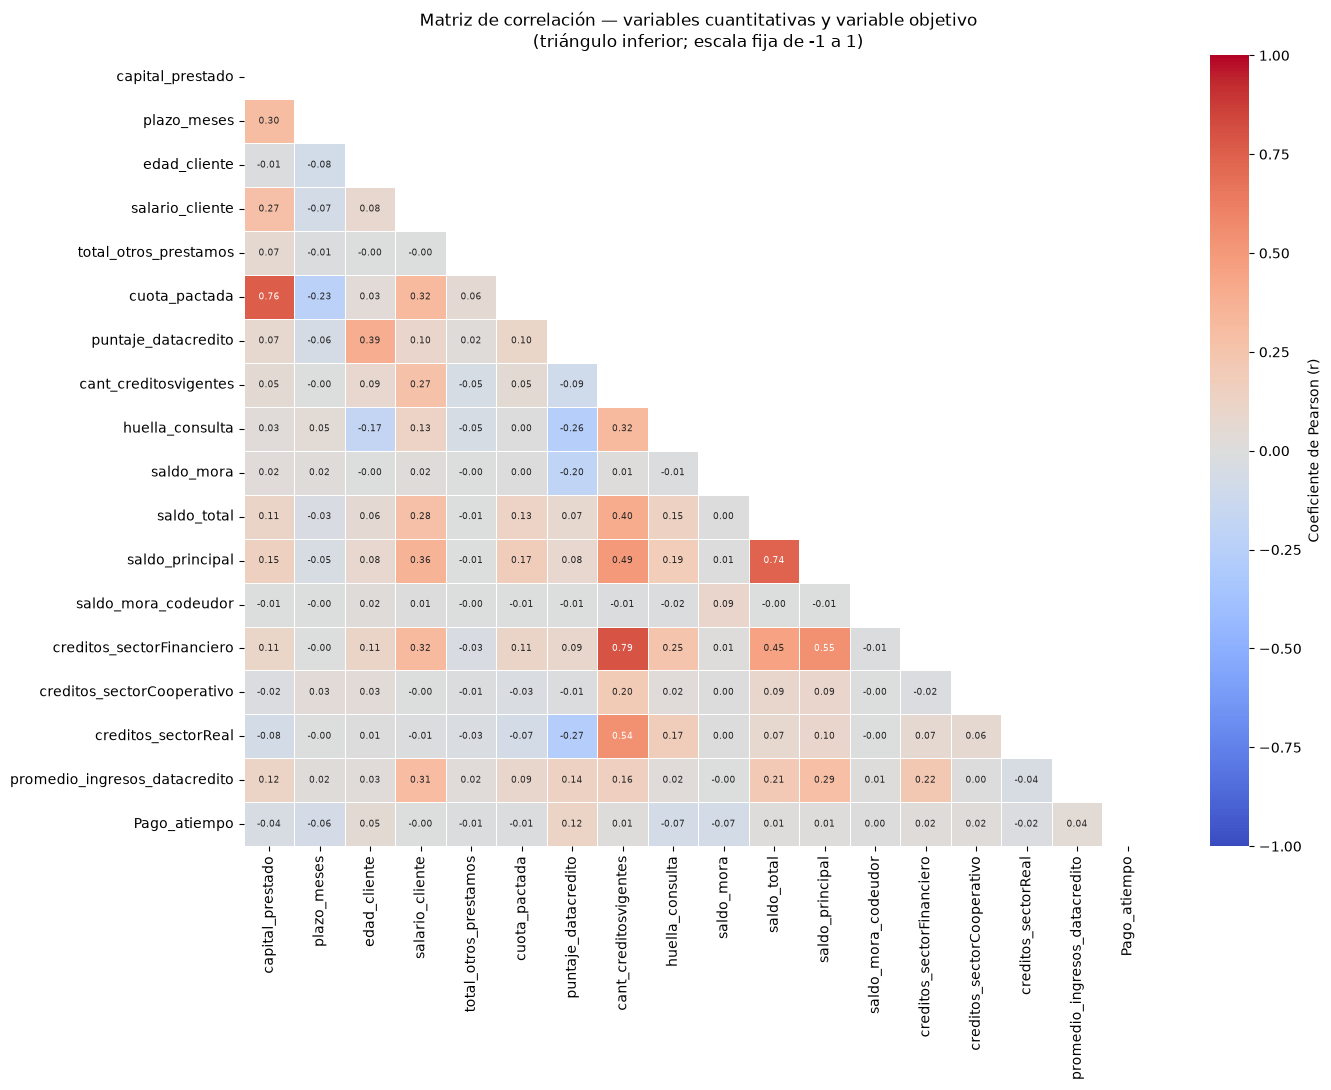

=== Correlación con la variable objetivo, ordenada por magnitud ===
puntaje_datacredito              0.1212
huella_consulta                  0.0737
saldo_mora                       0.0726
plazo_meses                      0.0631
edad_cliente                     0.0524
capital_prestado                 0.0406
promedio_ingresos_datacredito    0.0399
creditos_sectorReal              0.0233
creditos_sectorFinanciero        0.0214
creditos_sectorCooperativo       0.0213
saldo_total                      0.0149
saldo_principal                  0.0135
cuota_pactada                    0.0118
total_otros_prestamos            0.0100
cant_creditosvigentes            0.0088
salario_cliente                  0.0049
saldo_mora_codeudor              0.0026
Name: Pago_atiempo, dtype: float64

=== Pares de variables con multicolinealidad alta (|r| > 0.7) ===
  capital_prestado <-> cuota_pactada: r = 0.764
  cant_creditosvigentes <-> creditos_sectorFinanciero: r = 0.791
  saldo_total <-> saldo_principal: r 

In [31]:
# Matriz de correlación SOLO sobre variables cuantitativas reales.
# 'tipo_credito' queda excluida: la correlación de Pearson sobre un código nominal
# arroja r = 0.001 y OCULTA que ese producto va de 2.6% a 42.9% de tasa de mora
# según la categoría (ver análisis bivariado categórico, sección 3.2).
import seaborn as sns

num_corr = [c for c in VARS_NUMERICAS if c in df.columns] + [TARGET]

corr = df[num_corr].corr()

# Se dibuja solo el triangulo inferior (el superior es identico) y se anotan los
# coeficientes: con annot=False la figura no permitia leer ningun valor y obligaba
# a depender del print. La escala se fija en [-1, 1] para que las correlaciones
# negativas no queden comprimidas.
mascara = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mascara, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 6.5},
            linewidths=0.4, cbar_kws={'label': 'Coeficiente de Pearson (r)'})
plt.title('Matriz de correlación — variables cuantitativas y variable objetivo\n'
          '(triángulo inferior; escala fija de -1 a 1)')
plt.tight_layout()
plt.show()

print("=== Correlación con la variable objetivo, ordenada por magnitud ===")
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).round(4))

print("\n=== Pares de variables con multicolinealidad alta (|r| > 0.7) ===")
alta = (corr.abs() > 0.7) & (corr.abs() < 1.0)
pares = set()
for a in corr.columns:
    for b in corr.columns:
        if alta.loc[a, b] and (b, a) not in pares:
            pares.add((a, b))
            print(f"  {a} <-> {b}: r = {corr.loc[a, b]:.3f}")
if not pares:
    print("  Ninguno.")

#### Analisis matriz de correlación



**1. Frente a la variable objetivo, todo el panel está pálido.**
La fila de `Pago_atiempo` no muestra ninguna celda intensa. El valor más alto es
`puntaje_datacredito` con |r| = 0,1212, y el resto queda por debajo de 0,075. En una escala de 0
a 1, son correlaciones muy débiles.  significa
que **ninguna se relaciona con la mora de forma lineal y directa por sí sola**.

**2. Sí aparecen bloques intensos entre variables predictoras.** Se detectaron tres pares con
|r| > 0,7:

| Par de variables | r | Explicación |
|---|---|---|
| `cant_creditosvigentes` ↔ `creditos_sectorFinanciero` | +0,791 | El sector financiero concentra la mayoría de los créditos del cliente, así que ambos conteos crecen juntos |
| `capital_prestado` ↔ `cuota_pactada` | +0,764 | Relación mecánica: a mayor monto prestado, mayor cuota mensual |
| `saldo_total` ↔ `saldo_principal` | +0,737 | El saldo principal es un componente del saldo total |

**3. Las tres son redundancias esperables, no errores.** En los tres casos una variable contiene
parte de la información de la otra por construcción.

Incluir variables tan correlacionadas en un modelo lineal
distorsiona los coeficientes y dificulta explicar el peso real de cada factor, algo crítico en
riesgo crediticio donde hay que justificar la negación de un crédito. Convendrá conservar una de
cada par o emplear un modelo robusto a la multicolinealidad.

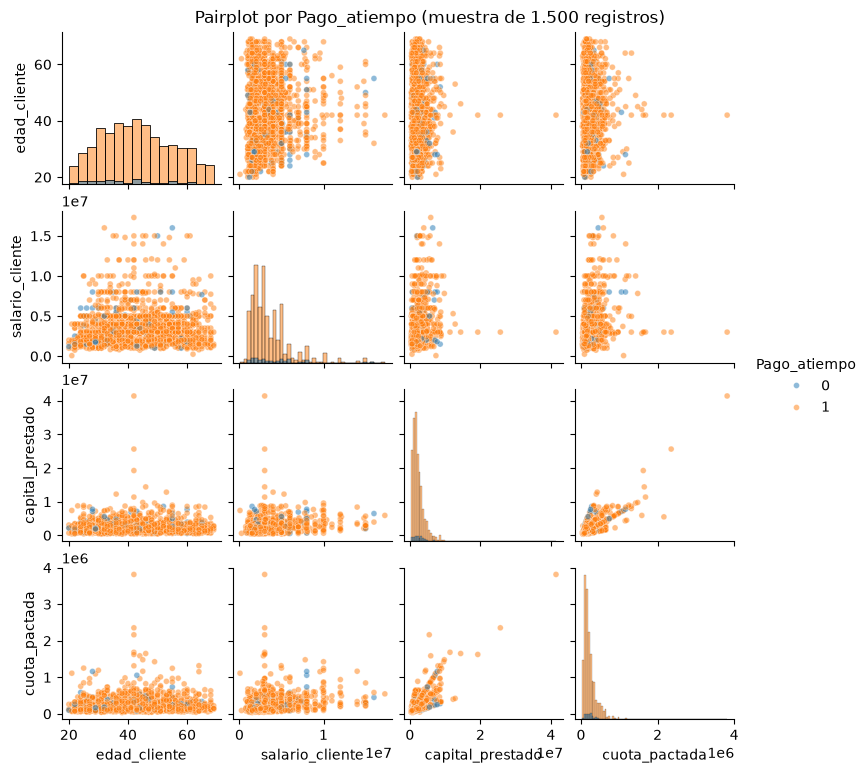

In [32]:
# Pairplot de un subconjunto de variables, coloreado por la variable objetivo (hue)
sub = ['edad_cliente', 'salario_cliente', 'capital_prestado', 'cuota_pactada', 'Pago_atiempo']
muestra = df[sub].dropna().sample(n=min(1500, len(df)), random_state=42)

sns.pairplot(muestra, hue='Pago_atiempo', diag_kind='hist',
             plot_kws={'alpha': 0.5, 's': 18}, height=1.9)
plt.suptitle('Pairplot por Pago_atiempo (muestra de 1.500 registros)', y=1.01)
plt.show()

#### Observaciones del pairplot



**1. Los puntos rojos no forman ningún grupo propio en estas cuatro variables.** En
`edad_cliente`, `salario_cliente`, `capital_prestado` y `cuota_pactada` los casos de mora aparecen
repartidos dentro de la misma nube que los créditos al día. Ninguna región de estos paneles
concentra la mora.

*Esta conclusión aplica a **estas cuatro variables**, no al dataset
completo. `puntaje_datacredito` no está incluido en el pairplot, y es justamente la variable donde
sí existe una región de concentración clara 

**Escasez de puntos rojos** Con solo 4,75% de casos de mora, y
usando una muestra de 1.500 registros, aparecen alrededor de 70 puntos rojos frente a más de
1.400 azules. 

**3. La única estructura clara no involucra a la variable objetivo.** El cruce
`capital_prestado` × `cuota_pactada` dibuja una línea ascendente definida, que corresponde a la
correlación de 0,764 ya detectada. Es una relación entre predictores, no una señal de riesgo.

**4. Los histogramas de la diagonal se superponen.** Para cada variable, la distribución de los
clientes en mora se solapa casi por completo con la de los clientes al día. Si alguna variable
separara bien las clases, veríamos dos curvas desplazadas una respecto de la otra.

Entre estas cuatro variables no existe un par que permita construir
una regla de decisión simple del tipo "si el capital supera X y la edad es menor que Y, entonces
hay riesgo". 

Esto respalda recurrir a un modelo multivariado en la Fase 3 en lugar de reglas de
negocio manuales sobre variables de perfil y monto.

In [33]:
# Tablas cruzadas: relación entre variables categóricas y la variable objetivo
print("=== tipo_laboral x tendencia_ingresos: tasa de mora (%) ===")
tabla = df.pivot_table(index='tipo_laboral', columns='tendencia_ingresos',
                       values='Pago_atiempo', aggfunc='mean')
print(((1 - tabla) * 100).round(2))

print("\n=== Conteo de registros por combinación ===")
print(pd.crosstab(df['tipo_laboral'], df['tendencia_ingresos']))

=== tipo_laboral x tendencia_ingresos: tasa de mora (%) ===
tendencia_ingresos  Creciente  Decreciente  Estable  Sin_dato
tipo_laboral                                                 
Empleado                 3.54         5.81     4.46      5.37
Independiente            4.78         7.32     4.77      6.01

=== Conteo de registros por combinación ===
tendencia_ingresos  Creciente  Decreciente  Estable  Sin_dato
tipo_laboral                                                 
Empleado                 3872          946      650      1286
Independiente            1463          355      545      1646


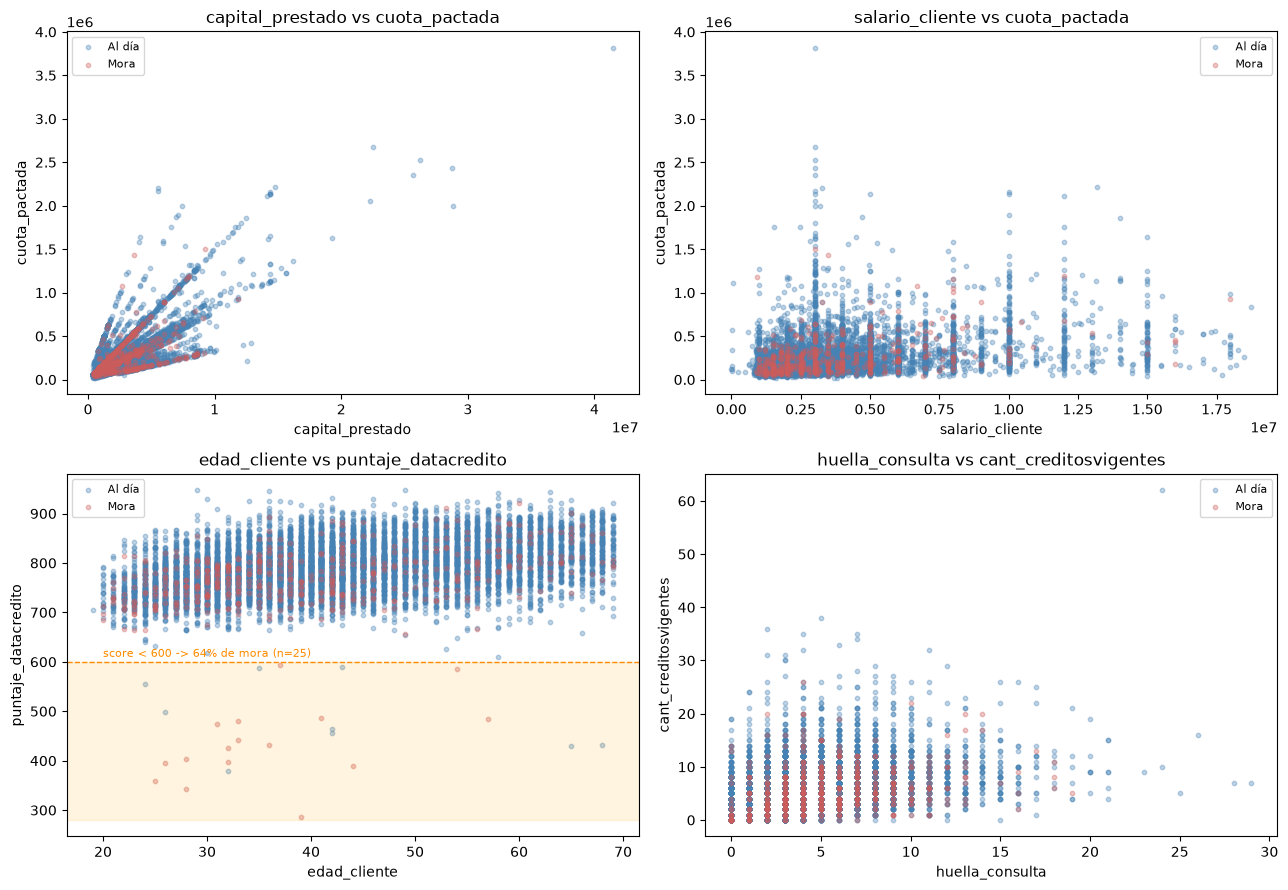

=== Verificacion: consultas por credito vigente vs tasa de mora ===
               n_creditos  tasa_mora_%
(-0.001, 0.3]        2233         2.78
(0.3, 0.5]           2626         3.54
(0.5, 0.714]         1635         4.95
(0.714, 1.0]         2133         5.06
(1.0, 15.0]          2136         7.82


In [34]:
# Gráficos de dispersión entre variables numéricas, coloreados por la variable objetivo (hue).
# Permiten ver simultáneamente la relación entre dos variables y el resultado de pago.
pares = [('capital_prestado', 'cuota_pactada'),
         ('salario_cliente', 'cuota_pactada'),
         ('edad_cliente', 'puntaje_datacredito'),
         ('huella_consulta', 'cant_creditosvigentes')]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for ax, (x, y) in zip(axes, pares):
    for clase, color, etiqueta in [(1, 'steelblue', 'Al día'), (0, 'indianred', 'Mora')]:
        sub = df[df[TARGET] == clase]
        ax.scatter(sub[x], sub[y], s=10, alpha=0.35, c=color, label=etiqueta)
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
    ax.legend(fontsize=8)
    # En el panel edad x score se resalta la zona por debajo de 600 puntos:
    # es la unica region del EDA donde la mora se concentra de forma evidente.
    if (x, y) == ('edad_cliente', 'puntaje_datacredito'):
        ax.axhspan(280, 600, color='orange', alpha=0.12)
        ax.axhline(600, color='darkorange', linestyle='--', linewidth=1)
        ax.text(20, 610, 'score < 600 -> 64% de mora (n=25)', fontsize=8, color='darkorange')
plt.tight_layout()
plt.show()

# Cifras que sustentan la lectura del panel huella_consulta vs cant_creditosvigentes.
# En un grafico de dispersion de dos variables enteras con 10.763 puntos superpuestos
# la concentracion no es verificable a ojo; se cuantifica con la variable derivada.
print("=== Verificacion: consultas por credito vigente vs tasa de mora ===")
_cpc = df['huella_consulta'] / (df['cant_creditosvigentes'] + 1)
_t = df.groupby(pd.qcut(_cpc, 5, duplicates='drop'), observed=True)['Pago_atiempo'].agg(['count', 'mean'])
_t['tasa_mora_%'] = ((1 - _t['mean']) * 100).round(2)
print(_t[['count', 'tasa_mora_%']].rename(columns={'count': 'n_creditos'}).to_string())

#### Analisis gráficos de dispersión

- **`capital_prestado` vs `cuota_pactada`**: relación lineal clara y esperable (r = 0,764) a
  mayor capital, mayor cuota. Es la multicolinealidad detectada en la matriz de correlación, y las
  bandas paralelas visibles corresponden a los distintos plazos pactados.

- **`salario_cliente` vs `cuota_pactada`**: la nube es difusa y aparecen líneas verticales en los
  valores redondos de salario ($2M, $3M, $5M), señal de que el ingreso es un dato **declarado y
  redondeado**, no medido. No existe una regla evidente que ligue el ingreso declarado con la
  cuota asignada.

- **`edad_cliente` vs `puntaje_datacredito`  Por debajo de
  los 600 puntos (zona sombreada) prácticamente todos los puntos son rojos de los 25 créditos en
  esa banda, **16 cayeron en mora (64%)**, frente al 4,75% de la cartera. Es la única región del
  análisis donde la mora se concentra de forma visualmente inequívoca. La observación adicional es
  que esos scores bajos aparecen sobre todo en clientes menores de 45 años.

  Tratar el score **por bandas** en lugar de como variable
  continua, ya que el riesgo no crece de forma lineal al bajar el puntaje sino que se dispara en
  el extremo inferior.

- **`huella_consulta` vs `cant_creditosvigentes`**: la impresión visual sugiere que la mora se
  concentra en la zona de muchas consultas con pocos créditos vigentes, pero **con dos variables
  enteras y 10.763 puntos superpuestos esa lectura no es verificable **. Por eso la celda
  cuantifica el patrón con la variable derivada `consultas_por_credito` la tasa de mora sube de
  **2,78% en el quintil más bajo a 7,82% en el más alto**, un gradiente monótono de 2,8 

  Se dice que muchas consultas en la central de riesgo con pocos créditos efectivamente
  abiertos sugiere solicitudes rechazadas o búsqueda intensa de financiación.

En los cuatro paneles los puntos rojos se mezclan con los
azules en la mayor parte del espacio. Salvo la banda de score bajo, ninguna combinación de dos
variables separa limpiamente a los clientes en mora, lo que refuerza que el riesgo depende de
varios factores simultáneos.

### Análisis multivariado (3.3)

- **Las correlaciones lineales con la variable objetivo son débiles en todo el panel.** Tras
  depurar los scores inválidos, `puntaje_datacredito` alcanza |r| = 0,1212 y es el máximo del
  dataset; le siguen `huella_consulta` (0,074), `saldo_mora` (0,073) y `plazo_meses` (0,063).
  **Esto significa que ninguna relación es lineal, no que no exista relación.** Las secciones 3.2.1
  y 3.2.2 muestran que las mismas variables sí discriminan riesgo cuando se analizan por tramos:
  el score va de 64% a 2,84% de mora entre bandas y el plazo de 3,91% a 12,66% entre tramos.
- **Multicolinealidad detectada en tres pares** (|r| > 0,7), todos por construcción y no por error
  de datos:

| Par | r | Causa |
|---|---|---|
| `cant_creditosvigentes` ↔ `creditos_sectorFinanciero` | +0,791 | El sector financiero concentra la mayoría de los créditos del cliente |
| `capital_prestado` ↔ `cuota_pactada` | +0,764 | Relación mecánica: a mayor monto, mayor cuota |
| `saldo_total` ↔ `saldo_principal` | +0,737 | El principal es un componente del total |

- **El pairplot sobre variables de perfil y monto no muestra
  ninguna región donde se concentre la mora. La excepción está en los gráficos de dispersión: la
  banda de `puntaje_datacredito` por debajo de 600 puntos concentra un 64% de mora. Es la única
  región del EDA con separación visual clara.

- **La tabla cruzada `tipo_laboral` × `tendencia_ingresos` muestra
  que el riesgo más alto se concentra en los independientes con ingresos decrecientes (7,32%) y el
  más bajo en los empleados con ingresos crecientes (3,54%), una diferencia de más del doble entre
  las dos combinaciones extremas. El orden se mantiene dentro de cada tipo laboral, lo que sugiere
  que ambos efectos se suman sin interacción cruzada fuerte.

# 4. Reglas de validación de datos

### 4.1 Diagnóstico previo: `total_otros_prestamos`

Antes de escribir las reglas conviene revisar la única variable monetaria que no pasó por la
limpieza de la sección 2. `salario_cliente` fue corregida por contener valores imposibles, pero
`total_otros_prestamos` que mide la misma clase de magnitud nunca fue examinada.

In [35]:
# Diagnostico de total_otros_prestamos: variable monetaria nunca revisada en la seccion 2,
# a diferencia de salario_cliente que si fue corregida por valores imposibles.
print("=== Diagnostico de total_otros_prestamos ===")
print(f"  minimo : {df['total_otros_prestamos'].min():>20,.0f} COP")
print(f"  mediana: {df['total_otros_prestamos'].median():>20,.0f} COP")
print(f"  P99    : {df['total_otros_prestamos'].quantile(0.99):>20,.0f} COP")
print(f"  P99.9  : {df['total_otros_prestamos'].quantile(0.999):>20,.0f} COP")
print(f"  maximo : {df['total_otros_prestamos'].max():>20,.0f} COP")
print(f"  skewness: {df['total_otros_prestamos'].skew():.1f}")

print(f"\n  Registros por encima de 1.000 millones: {(df['total_otros_prestamos'] > 1_000_000_000).sum()}")
ratio_deuda_salario = df['total_otros_prestamos'] / df['salario_cliente']
print(f"  Registros donde otras deudas superan 100 veces el salario mensual: "
      f"{(ratio_deuda_salario > 100).sum()}")

# Trazabilidad SIN imputar: se marca lo sospechoso pero no se fabrica un valor.
# Motivo: a diferencia del salario, aqui no existe una regla de negocio que permita
# distinguir un endeudamiento corporativo legitimo de un error de digitacion, y son
# pocos registros. Imputar seria inventar; eliminarlos, perder informacion.
df['total_otros_prestamos_sospechoso'] = (
    (df['total_otros_prestamos'] > 1_000_000_000) | (ratio_deuda_salario > 100)
).astype(int)
print(f"\n  Marcados como sospechosos (bandera, sin imputar): "
      f"{df['total_otros_prestamos_sospechoso'].sum()}")

_ = contraste_tasas("total_otros_prestamos_sospechoso == 1",
                    df['total_otros_prestamos_sospechoso'] == 1)

=== Diagnostico de total_otros_prestamos ===
  minimo :                    0 COP
  mediana:            1,000,000 COP
  P99    :           17,946,060 COP
  P99.9  :        1,231,431,206 COP
  maximo :        6,787,675,263 COP
  skewness: 38.5

  Registros por encima de 1.000 millones: 13
  Registros donde otras deudas superan 100 veces el salario mensual: 30

  Marcados como sospechosos (bandera, sin imputar): 30
total_otros_prestamos_sospechoso == 1
   Grupo : n=    30  mora=   2  tasa=  6.67%   IC95% Wilson = [1.85% , 21.32%]
   Resto : n=10,733  tasa=  4.74%
   Odds Ratio =   1.43 | p (Fisher exacto) = 0.6522  ->  NO SIGNIFICATIVO (p>=0.05)



**Decisión `total_otros_prestamos` alcanza un máximo de $6.787 millones, con una
asimetría de 38,5. Existen 13 registros por encima de mil millones y 30 donde el endeudamiento
declarado supera 100 veces el salario mensual del cliente.

**No se imputan.** El criterio es distinto al aplicado a `salario_cliente` por una razón concreta:
en el salario existía un límite defendible (el método IQR sobre escala logarítmica, apoyado en la
distribución observada) y una interpretación clara del error (probable captura del ingreso anual
como mensual). Aquí no hay ninguna regla de negocio disponible que permita distinguir un
endeudamiento corporativo legítimo de un error de digitación, y son muy pocos registros.
Fabricar un valor sería inventar información; eliminarlos, perderla.

**Tratamiento aplicado:** se marca con la bandera `total_otros_prestamos_sospechoso` y se define
una regla de validación con techo, de modo que en producción estos casos queden señalados en lugar
de pasar silenciosamente. La decisión definitiva —recortar, transformar con log1p o excluir— se
toma en la Fase 2, cuando se conozca la sensibilidad del modelo elegido a estos extremos.


In [36]:
# Reglas de validación derivadas del DICCIONARIO DE DATOS y de fuentes oficiales.
# Reutilizables en etapas posteriores del pipeline (ft_engineering.py, model_deploy.py)
# y para validar datos nuevos en producción.
#
# CORRECCIÓN APLICADA: el rango de 'puntaje_datacredito' era [0, 1000], un rango
# inventado sin fuente. El rango oficial de DataCrédito Experian es [150, 950].
# La regla anterior detectaba 1 solo registro inválido; la corregida detecta 153.

REGLAS_VALIDACION = {
    'edad_cliente':          {'min': 18,   'max': 90,         'nulos_permitidos': False,
                              'fuente': 'Mayoría de edad legal + brecha observada en la distribución (70-120)'},
    'salario_cliente':       {'min': 1,    'max': 20_000_000, 'nulos_permitidos': False,
                              'fuente': 'Límite IQR sobre escala logarítmica (~18.79M), redondeado'},
    'capital_prestado':      {'min': 1,    'max': 50_000_000, 'nulos_permitidos': False,
                              'fuente': 'Máximo observado 41.4M + margen'},
    'plazo_meses':           {'min': 1,    'max': 120,        'nulos_permitidos': False,
                              'fuente': 'Máximo observado 90 meses + margen comercial'},
    'cuota_pactada':         {'min': 1,    'max': 5_000_000,  'nulos_permitidos': False,
                              'fuente': 'Rango observado'},
    'puntaje_datacredito':   {'min': 150,  'max': 950,        'nulos_permitidos': True,
                              'fuente': 'Rango oficial DataCrédito Experian (Términos y Condiciones Midatacrédito). '
                                        'Nulos permitidos: representan ausencia de historial (ver sección 2.4)'},
    'cant_creditosvigentes': {'min': 0,    'max': 100,        'nulos_permitidos': False,
                              'fuente': 'Máximo observado 62 + margen'},
    'huella_consulta':       {'min': 0,    'max': 50,         'nulos_permitidos': False,
                              'fuente': 'Máximo observado 30 + margen'},
    'saldo_mora':            {'min': 0,    'max': None,       'nulos_permitidos': False,
                              'fuente': 'Un saldo no puede ser negativo'},
    'saldo_total':           {'min': 0,    'max': None,       'nulos_permitidos': False,
                              'fuente': 'Un saldo no puede ser negativo'},
    'saldo_principal':       {'min': 0,    'max': None,       'nulos_permitidos': False,
                              'fuente': 'Un saldo no puede ser negativo'},
    'saldo_mora_codeudor':   {'min': 0,    'max': None,       'nulos_permitidos': False,
                              'fuente': 'Un saldo no puede ser negativo'},
    'tipo_credito':          {'valores': [4, 6, 7, 9, 10, 68], 'nulos_permitidos': False,
                              'fuente': 'Códigos observados en el dataset (significado sin confirmar)'},
    'tipo_laboral':          {'valores': ['Empleado', 'Independiente'], 'nulos_permitidos': False,
                              'fuente': 'Dominio cerrado observado'},
    'tendencia_ingresos':    {'valores': ['Creciente', 'Decreciente', 'Estable', 'Sin_dato'],
                              'nulos_permitidos': False,
                              'fuente': 'Dominio cerrado tras reconstrucción (sección 2.4)'},
    'Pago_atiempo':          {'valores': [0, 1], 'nulos_permitidos': False,
                              'fuente': 'Variable objetivo binaria'},
    # --- Reglas anadidas: estas 6 variables no tenian regla y pasaban sin validar ---
    'total_otros_prestamos': {'min': 0,    'max': 1_000_000_000, 'nulos_permitidos': False,
                              'fuente': 'Un monto de deuda no puede ser negativo. Techo de 1.000M: '
                                        'por encima hay 13 registros no verificables (ver 4.1); '
                                        'la regla los senala en vez de dejarlos pasar'},
    'promedio_ingresos_datacredito': {'min': 0, 'max': 50_000_000, 'nulos_permitidos': True,
                              'fuente': 'Maximo observado 38.1M + margen. Nulos permitidos: 27% de '
                                        'ausencia sin causa estructural, conservada como informacion (2.2)'},
    'creditos_sectorFinanciero': {'min': 0, 'max': 100, 'nulos_permitidos': False,
                              'fuente': 'Maximo observado 51 + margen'},
    'creditos_sectorCooperativo': {'min': 0, 'max': 50, 'nulos_permitidos': False,
                              'fuente': 'Maximo observado 13 + margen'},
    'creditos_sectorReal':   {'min': 0,    'max': 100,        'nulos_permitidos': False,
                              'fuente': 'Maximo observado 25 + margen'},
    'fecha_prestamo':        {'min_fecha': '2020-01-01', 'max_fecha': 'hoy', 'nulos_permitidos': False,
                              'fuente': 'Una fecha de desembolso no puede ser futura ni anterior al '
                                        'inicio de operacion del producto. Rango observado: '
                                        '2024-11-26 a 2026-04-26'},
}


def validar_dataframe(datos, reglas=REGLAS_VALIDACION):
    """Valida un DataFrame contra las reglas definidas. Devuelve lista de violaciones."""
    violaciones = []
    for col, regla in reglas.items():
        if col not in datos.columns:
            violaciones.append(f"{col}: columna ausente")
            continue
        if not regla.get('nulos_permitidos', True) and datos[col].isnull().any():
            violaciones.append(f"{col}: {datos[col].isnull().sum()} nulos no permitidos")
        serie = datos[col].dropna()
        if 'min_fecha' in regla:
            # Regla temporal: la fecha no puede ser futura ni anterior al inicio del producto
            limite_inf = pd.Timestamp(regla['min_fecha'])
            limite_sup = pd.Timestamp.today() if regla['max_fecha'] == 'hoy' else pd.Timestamp(regla['max_fecha'])
            serie_fecha = pd.to_datetime(serie, errors='coerce')
            if (serie_fecha < limite_inf).any():
                violaciones.append(f"{col}: {(serie_fecha < limite_inf).sum()} fechas anteriores a {regla['min_fecha']}")
            if (serie_fecha > limite_sup).any():
                violaciones.append(f"{col}: {(serie_fecha > limite_sup).sum()} fechas futuras")
        elif 'valores' in regla:
            invalidos = ~serie.isin(regla['valores'])
            if invalidos.any():
                violaciones.append(f"{col}: {invalidos.sum()} valores fuera del dominio permitido")
        else:
            if regla.get('min') is not None and (serie < regla['min']).any():
                violaciones.append(f"{col}: {(serie < regla['min']).sum()} valores bajo el mínimo ({regla['min']})")
            if regla.get('max') is not None and (serie > regla['max']).any():
                violaciones.append(f"{col}: {(serie > regla['max']).sum()} valores sobre el máximo ({regla['max']})")
    return violaciones


print("=== Validación del dataset ya limpio ===")
resultado = validar_dataframe(df)
if resultado:
    for v in resultado:
        print(" -", v)
else:
    print("Sin violaciones: el dataset cumple todas las reglas definidas.")

print("\n=== Comprobación del impacto de la corrección ===")
crudo = pd.read_csv(RUTA_CRUDO, sep=';', encoding='utf-8-sig')
regla_anterior = ((crudo['puntaje_datacredito'] < 0) | (crudo['puntaje_datacredito'] > 1000)).sum()
regla_corregida = ((crudo['puntaje_datacredito'] < 150) | (crudo['puntaje_datacredito'] > 950)).sum()
print(f"Registros inválidos detectados con la regla anterior [0, 1000]: {regla_anterior}")
print(f"Registros inválidos detectados con la regla corregida [150, 950]: {regla_corregida}")
print(f"Registros que pasaban silenciosamente: {regla_corregida - regla_anterior}")

=== Validación del dataset ya limpio ===
 - total_otros_prestamos: 13 valores sobre el máximo (1000000000)

=== Comprobación del impacto de la corrección ===
Registros inválidos detectados con la regla anterior [0, 1000]: 1
Registros inválidos detectados con la regla corregida [150, 950]: 153
Registros que pasaban silenciosamente: 152


### Reglas de validación 

Los rangos se derivan del diccionario de datos y de fuentes verificables, no de criterios
arbitrarios. Cada regla lleva su campo `fuente` en el código.

| Variable | Rango | Origen del criterio |
|---|---|---|
| `edad_cliente` | [18, 90] | Mayoría de edad legal; el techo se apoya en la brecha vacía observada entre 70 y 120 años |
| `salario_cliente` | [1, 20.000.000] | Límite IQR sobre escala logarítmica (~$18.79M), redondeado al alza |
| `puntaje_datacredito` | **[150, 950]** | **Rango oficial DataCrédito Experian.** Corrige el rango [0, 1000] usado antes, que no tenía fuente |
| `plazo_meses` | [1, 120] | Máximo observado 90 meses, con margen comercial |
| `total_otros_prestamos` | [0, 1.000.000.000] | Techo que señala los 13 registros no verificables detectados en 4.1 |
| `fecha_prestamo` | No futura, no anterior a 2020 | Una fecha de desembolso posterior a hoy es imposible; regla clave para validar datos nuevos en producción |
| Conteos por sector | [0, techo observado + margen] | Máximos observados 51 / 13 / 25 |
| Dominios categóricos | Listas cerradas | Cualquier valor fuera indica corrupción, como los 58 registros numéricos hallados en `tendencia_ingresos` |

**Cobertura:** las reglas cubren las 22 variables del dataset.

# 5. Identificación del atributo objetivo (target)

In [37]:
# Declaración explícita de la variable objetivo (target)
TARGET = 'Pago_atiempo'

print(f"Variable objetivo: {TARGET}")
print(f"Tipo: categórica binaria (dicotómica)")
print("\nDistribución de clases:")
dist = df[TARGET].value_counts()
dist_pct = df[TARGET].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({'registros': dist, 'porcentaje': dist_pct}))

ratio = dist.max() / dist.min()
print(f"\nRatio de desbalance: {ratio:.1f} a 1")
print(f"Clase minoritaria (mora, 0): {dist.get(0, 0)} registros ({dist_pct.get(0, 0)}%)")

Variable objetivo: Pago_atiempo
Tipo: categórica binaria (dicotómica)

Distribución de clases:
              registros  porcentaje
Pago_atiempo                       
1                 10252       95.25
0                   511        4.75

Ratio de desbalance: 20.1 a 1
Clase minoritaria (mora, 0): 511 registros (4.75%)


### Atributo objetivo 

**`Pago_atiempo`** es la variable objetivo del proyecto: indica si el crédito se pagó a tiempo (1) o cayó en mora (0). Esto define el problema como **clasificación binaria supervisada**, alineado con la pregunta de negocio planteada en el enunciado (evaluar el pago del crédito).

Consideraciones críticas para las fases siguientes:

1. **Fuerte desbalance de clases (~20 a 1)**: solo el 4.75% de los registros corresponde a mora. Un modelo que prediga siempre "paga a tiempo" alcanzaría 95.25% de exactitud sin aprender nada útil. Por lo tanto, **la exactitud (accuracy) no es una métrica válida** deben usarse precisión, recall, F1 y AUC-PR, priorizando el recall sobre la clase minoritaria (detectar la mora es el objetivo de negocio).

2. **Técnicas de balanceo a evaluar**: `class_weight='balanced'`, submuestreo, o SMOTE aplicadas únicamente sobre el conjunto de entrenamiento

3. **Riesgo de fuga de información (data leakage)**: variables como `saldo_mora` y `saldo_mora_codeudor` describen mora ya existente. Debe confirmarse con el negocio si se registran **antes** del desembolso (información válida del historial) o **después** (contaminarían el modelo, ya que serían consecuencia y no causa del impago). Esta validación es imprescindible antes de entrenar.

4. **La etiqueta no es homogénea en el tiempo** (ver sección 3.2.2). La tasa de mora varía entre 1,72% y 9,09% según el mes de desembolso, y el **19,9% de los créditos tiene un plazo pactado que vence después de la última fecha del dataset**: para esos registros, `Pago_atiempo` refleja el estado observado al corte, no el desenlace final. Su tasa de mora es significativamente mayor (6,40% vs 4,34%, p = 0,0001). Consecuencias:
   - Debe evaluarse un **split temporal** además del aleatorio en la Fase 3.
   - Debe confirmarse con el negocio **cómo y cuándo se asigna** el valor de `Pago_atiempo`.
   - La serie mensual de tasa de mora es la **línea base de monitoreo** para la Fase 5.
   
5. **Ausencia de identificador de cliente**: la unidad de observación es el crédito. Sin identificador no puede aplicarse un split agrupado por cliente (`GroupShuffleSplit`), lo que introduce riesgo de fuga si un mismo cliente aparece en varias filas. Debe declararse al reportar métricas.

# 6. Transformaciones futuras aplicables

In [38]:
# Identificación de transformaciones aplicables en la fase de Feature Engineering

transformaciones = [
    ('tipo_laboral',        'One-Hot Encoding',        'Categórica dicotómica nominal; genera 1 columna binaria'),
    ('tendencia_ingresos',  'One-Hot Encoding',        'Categórica politómica (4 niveles, incluye Sin_dato como categoría informativa)'),
    ('tipo_credito',        'One-Hot / agrupación',    'Nominal con 6 niveles muy desbalanceados; agrupar los de baja frecuencia (7, 68, 6) en "Otros"'),
    ('capital_prestado',    'Transformación log',      'Skewness 3.72; log reduce el sesgo y la influencia de valores extremos'),
    ('salario_cliente',     'Transformación log',      'Skewness 2.20; variable monetaria fuertemente asimétrica'),
    ('cuota_pactada',       'Transformación log',      'Skewness 3.79'),
    ('total_otros_prestamos','Transformación log1p',   'Skewness 38.5 y contiene ceros; log1p maneja el cero correctamente'),
    ('saldos (4 columnas)', 'log1p + indicador binario','Alta concentración en cero; el indicador "tiene saldo" puede ser más informativo que el monto'),
    ('variables numéricas', 'Escalado robusto',        'RobustScaler resiste mejor los atípicos que StandardScaler, necesario si se usan modelos sensibles a escala'),
    ('fecha_prestamo',      'Extracción temporal',     'Derivar mes, trimestre y antigüedad del crédito; la fecha cruda no es utilizable como predictor'),
    ('promedio_ingresos_datacredito', 'Imputación + flag', 'Decisión diferida: si el modelo no admite NaN (regresión logística), imputar y conservar el indicador de ausencia. La BANDERA se conserva siempre: es predictor significativo (seccion 3.2.3)'),
    # --- Transformaciones anadidas a partir de los hallazgos de las secciones 3.2.1 a 3.2.3 ---
    ('puntaje_datacredito',  'Binning por bandas',      'La relacion con la mora NO es lineal: 64% de mora bajo 600 pts vs 2.9% sobre 850 (seccion 3.2.1). Tratar por bandas conserva esa estructura; como continua se pierde'),
    ('plazo_meses',          'Binning por tramos',      'Relacion no monotona: 4.76% (0-6m), 3.91% (6-12m), 12.66% (24-36m). Como numero continuo el modelo lineal no puede capturarla (seccion 3.2.1)'),
    ('banderas de ausencia', 'Conservar como binarias', 'promedio_ingresos_era_nulo, saldo_principal_era_nulo y saldo_mora_codeudor_era_nulo son predictores significativos (seccion 3.2.3). No eliminar como metadatos'),
    ('fecha_prestamo',       'Antiguedad + cohorte',    'Ademas de mes/trimestre: dias desde el desembolso hasta la fecha de corte, y bandera de madurez incompleta (seccion 3.2.2)'),
    ('total_otros_prestamos','log1p + revision de extremos', 'Skewness 38.5 con 13 registros sobre 1.000M sin verificar (seccion 4.1). Decidir recorte o exclusion antes de usar los ratios que la dividen'),
]

plan = pd.DataFrame(transformaciones, columns=['Variable', 'Transformación', 'Justificación'])
print(plan.to_string(index=False))

                     Variable               Transformación                                                                                                                                                                                 Justificación
                 tipo_laboral             One-Hot Encoding                                                                                                                                       Categórica dicotómica nominal; genera 1 columna binaria
           tendencia_ingresos             One-Hot Encoding                                                                                                                Categórica politómica (4 niveles, incluye Sin_dato como categoría informativa)
                 tipo_credito         One-Hot / agrupación                                                                                                Nominal con 6 niveles muy desbalanceados; agrupar los de baja frecuencia (7, 68, 6) en "Otros"
    

# 7. Atributos adicionales (derivados/calculados)

In [39]:
# Atributos derivados propuestos, construidos con lógica de negocio financiero.
# Se calculan aquí para EVALUAR su valor predictivo; su implementación definitiva
# corresponde a la fase de Feature Engineering (ft_engineering.py).

derivadas = df.copy()

# 1. Capacidad de pago: qué porcentaje del ingreso consume la cuota del crédito
derivadas['ratio_cuota_ingreso'] = derivadas['cuota_pactada'] / derivadas['salario_cliente']

# 2. Nivel de endeudamiento previo respecto al ingreso
derivadas['ratio_deuda_ingreso'] = derivadas['total_otros_prestamos'] / derivadas['salario_cliente']

# 3. Magnitud del crédito respecto al ingreso mensual
derivadas['ratio_capital_ingreso'] = derivadas['capital_prestado'] / derivadas['salario_cliente']

# 4. Presencia de mora previa (señal binaria, más robusta que el monto)
derivadas['tiene_mora_previa'] = (derivadas['saldo_mora'] > 0).astype(int)

# 5. Diversificación de crédito: total de créditos across sectores
derivadas['total_creditos_sectores'] = derivadas[['creditos_sectorFinanciero',
                                                  'creditos_sectorCooperativo',
                                                  'creditos_sectorReal']].sum(axis=1)

# 6. Intensidad de búsqueda de crédito: consultas por crédito vigente
derivadas['consultas_por_credito'] = derivadas['huella_consulta'] / (derivadas['cant_creditosvigentes'] + 1)

# 7. Discrepancia entre el ingreso declarado y el reportado en central de riesgo
derivadas['discrepancia_ingresos'] = (
    derivadas['salario_cliente'] - derivadas['promedio_ingresos_datacredito']
) / derivadas['salario_cliente']

# 8. Componentes temporales de la fecha de préstamo
derivadas['mes_prestamo'] = derivadas['fecha_prestamo'].dt.month
derivadas['trimestre_prestamo'] = derivadas['fecha_prestamo'].dt.quarter

nuevas = ['ratio_cuota_ingreso', 'ratio_deuda_ingreso', 'ratio_capital_ingreso',
          'tiene_mora_previa', 'total_creditos_sectores', 'consultas_por_credito',
          'discrepancia_ingresos', 'mes_prestamo', 'trimestre_prestamo']

print("Atributos derivados creados:", len(nuevas))
print(derivadas[nuevas].describe().T)

Atributos derivados creados: 9
                           count      mean        std        min       25%  \
ratio_cuota_ingreso      10763.0  0.098927   1.242397   0.003107  0.040208   
ratio_deuda_ingreso      10763.0  2.250027  45.960172   0.000000  0.213192   
ratio_capital_ingreso    10763.0  0.961538   8.337129   0.040200  0.387905   
tiene_mora_previa        10763.0  0.005110   0.071305   0.000000  0.000000   
total_creditos_sectores  10763.0  4.352504   3.489233   0.000000  2.000000   
consultas_por_credito    10763.0  0.774194   0.723288   0.000000  0.333333   
discrepancia_ingresos     7833.0  0.353508   0.554426 -18.053290  0.070140   
mes_prestamo             10763.0  5.274087   3.717484   1.000000  2.000000   
trimestre_prestamo       10763.0  2.105640   1.128308   1.000000  1.000000   

                              50%       75%       max  
ratio_cuota_ingreso      0.062852  0.099123   125.802  
ratio_deuda_ingreso      0.343758  0.485603  2439.000  
ratio_capital_ingres

In [40]:
# Evaluación del poder predictivo de los atributos derivados frente a la variable objetivo
print("=== Correlación con Pago_atiempo (derivadas vs originales) ===")
cols_eval = nuevas + ['huella_consulta', 'puntaje_datacredito', 'plazo_meses', 'edad_cliente']
corr_eval = derivadas[cols_eval + ['Pago_atiempo']].corr()['Pago_atiempo'].drop('Pago_atiempo')
print(corr_eval.abs().sort_values(ascending=False).round(4))

print("\n=== Tasa de mora según 'tiene_mora_previa' ===")
tasa_mora_previa = (1 - derivadas.groupby('tiene_mora_previa')['Pago_atiempo'].mean()) * 100
conteo = derivadas['tiene_mora_previa'].value_counts()
print(pd.DataFrame({'registros': conteo, 'tasa_mora_%': tasa_mora_previa.round(2)}))

# Quintiles de los TRES ratios de capacidad de pago. Antes solo se calculaba el de
# cuota/ingreso, pero el analisis escrito citaba tambien cifras de deuda/ingreso:
# se calculan los tres para que toda afirmacion quede sustentada por un output.
print("\n=== Tasa de mora por quintil de cada ratio de capacidad de pago ===")
etiquetas = ['Q1 (menor)', 'Q2', 'Q3', 'Q4', 'Q5 (mayor)']
tabla_quintiles = {}
for ratio in ['ratio_cuota_ingreso', 'ratio_deuda_ingreso', 'ratio_capital_ingreso']:
    q = pd.qcut(derivadas[ratio], 5, labels=etiquetas, duplicates='drop')
    tabla_quintiles[ratio] = ((1 - derivadas.groupby(q, observed=True)['Pago_atiempo'].mean()) * 100).round(2)
print(pd.DataFrame(tabla_quintiles).to_string())
print(f"    (tasa base de la cartera: {(1 - derivadas['Pago_atiempo'].mean())*100:.2f}%)")

# --- CONTRASTE DE LA HIPOTESIS SOBRE LOS RATIOS ---
# El analisis previo atribuia la correlacion casi nula de los ratios a los 250 salarios
# imputados con la mediana. Es una hipotesis verificable: basta recalcular la correlacion
# excluyendo esos registros. Se comprueba antes de darla por buena.
print("\n=== ¿Los ratios fallan por los salarios imputados? Contraste directo ===")
imputado = derivadas['salario_cliente_corregido'].astype(bool)
print(f"Registros con salario imputado: {imputado.sum()} ({imputado.mean()*100:.2f}% del total)\n")
comparacion_ratios = []
for ratio in ['ratio_cuota_ingreso', 'ratio_deuda_ingreso', 'ratio_capital_ingreso']:
    r_todos = derivadas[ratio].corr(derivadas['Pago_atiempo'])
    r_limpios = derivadas.loc[~imputado, ratio].corr(derivadas.loc[~imputado, 'Pago_atiempo'])
    comparacion_ratios.append({'ratio': ratio, 'r_con_imputados': round(r_todos, 4),
                               'r_sin_imputados': round(r_limpios, 4),
                               'cambio_abs': round(abs(r_limpios) - abs(r_todos), 4)})
print(pd.DataFrame(comparacion_ratios).to_string(index=False))
print("\nLectura: si la hipotesis fuera correcta, |r| deberia subir de forma apreciable")
print("al excluir los registros imputados.")

=== Correlación con Pago_atiempo (derivadas vs originales) ===
puntaje_datacredito        0.1212
tiene_mora_previa          0.1065
consultas_por_credito      0.0765
huella_consulta            0.0737
plazo_meses                0.0631
edad_cliente               0.0524
discrepancia_ingresos      0.0382
trimestre_prestamo         0.0101
total_creditos_sectores    0.0090
mes_prestamo               0.0088
ratio_deuda_ingreso        0.0072
ratio_cuota_ingreso        0.0028
ratio_capital_ingreso      0.0002
Name: Pago_atiempo, dtype: float64

=== Tasa de mora según 'tiene_mora_previa' ===
                   registros  tasa_mora_%
tiene_mora_previa                        
0                      10708         4.59
1                         55        36.36

=== Tasa de mora por quintil de cada ratio de capacidad de pago ===
            ratio_cuota_ingreso  ratio_deuda_ingreso  ratio_capital_ingreso
Q1 (menor)                 4.27                 6.86                   4.13
Q2                     



Las secciones 3.2.1 y 3.2.2 mostraron que la correlación de Pearson subestima de forma sistemática
la utilidad de una variable cuando el target es binario y desbalanceado. Para ordenar las
candidatas de la Fase 2 con un criterio más adecuado se calcula el **Information Value (IV)**, la
medida estándar en construcción de *scorecards* crediticios.

El IV segmenta la variable en tramos y mide cuánto se separan, entre tramo y tramo, la
distribución de clientes en mora y la de clientes al día. A diferencia de Pearson, **no exige que
la relación sea lineal**. Su escala de lectura convencional en el sector es: menos de 0,02 sin
poder predictivo; 0,02–0,1 débil; 0,1–0,3 medio; 0,3–0,5 fuerte; por encima de 0,5 sospechoso de
fuga de información

Se presenta junto a la correlación para que la comparación sea explícita.

In [41]:
# Information Value: mide separacion entre clases por tramos, sin asumir linealidad.
# Se calcula sobre las mismas variables ya evaluadas con Pearson para comparar.

def information_value(serie, objetivo, bins=10):
    """IV de una variable frente al target binario. Devuelve NaN si no es calculable."""
    serie = pd.Series(serie)
    if serie.dtype.kind in 'ifc' and serie.nunique() > bins:
        tramos = pd.qcut(serie, bins, duplicates='drop')
    else:
        tramos = serie.astype(str)
    tabla = pd.crosstab(tramos, objetivo)
    if tabla.shape[1] < 2:
        return float('nan')
    al_dia = tabla[1] / tabla[1].sum()
    en_mora = tabla[0] / tabla[0].sum()
    al_dia = al_dia.replace(0, 1e-4)
    en_mora = en_mora.replace(0, 1e-4)
    return float(((en_mora - al_dia) * np.log(en_mora / al_dia)).sum())


def fuerza_iv(v):
    if v != v:
        return '-'
    if v < 0.02:
        return 'sin poder predictivo'
    if v < 0.1:
        return 'debil'
    if v < 0.3:
        return 'medio'
    if v < 0.5:
        return 'fuerte'
    return 'sospechoso de fuga'


vars_iv = (nuevas + ['puntaje_datacredito', 'huella_consulta', 'plazo_meses', 'edad_cliente',
                     'capital_prestado', 'cuota_pactada', 'salario_cliente',
                     'total_otros_prestamos', 'cant_creditosvigentes',
                     'promedio_ingresos_datacredito', 'tipo_credito', 'tipo_laboral',
                     'tendencia_ingresos', 'promedio_ingresos_datacredito_era_nulo'])

filas_iv = []
for col in vars_iv:
    if col not in derivadas.columns:
        continue
    iv = information_value(derivadas[col], derivadas['Pago_atiempo'])
    try:
        r = abs(pd.to_numeric(derivadas[col], errors='coerce').corr(derivadas['Pago_atiempo']))
    except Exception:
        r = float('nan')
    filas_iv.append({'variable': col, 'IV': round(iv, 4),
                     'interpretacion_IV': fuerza_iv(iv), '|pearson|': round(r, 4)})

ranking_iv = pd.DataFrame(filas_iv).sort_values('IV', ascending=False)
print("=== Ranking por Information Value (comparado con la correlacion de Pearson) ===")
print(ranking_iv.to_string(index=False))

=== Ranking por Information Value (comparado con la correlacion de Pearson) ===
                              variable     IV    interpretacion_IV  |pearson|
                   puntaje_datacredito 0.2136                medio     0.1212
                 consultas_por_credito 0.1637                medio     0.0765
                       huella_consulta 0.1455                medio     0.0737
                           plazo_meses 0.1278                medio     0.0631
         promedio_ingresos_datacredito 0.1069                medio     0.0399
                 discrepancia_ingresos 0.0930                debil     0.0382
                     tiene_mora_previa 0.0884                debil     0.1065
                          edad_cliente 0.0831                debil     0.0524
                      capital_prestado 0.0745                debil     0.0406
                   ratio_deuda_ingreso 0.0726                debil     0.0072
                 total_otros_prestamos 0.0539                d

### Analisis de los atributos derivados

Se propusieron 9 atributos derivados con lógica de negocio financiero y se midió su relación con la
variable objetivo mediante dos medidas complementarias: **correlación de Pearson** (relación
lineal) e **Information Value** (capacidad de discriminación por tramos, sin asumir linealidad).
 se calculan en un DataFrame independiente solo para
decidir cuáles construir en la Fase 2.

#### 1. `consultas_por_credito` el atributo derivado más valioso

Se calcula como `huella_consulta ÷ (cant_creditosvigentes + 1)`. Alcanza **IV = 0,1637 (poder
medio)**, el segundo valor más alto de todo el dataset y por encima de la variable original de la
que deriva (`huella_consulta`, IV = 0,1455).  la tasa de
mora sube de **2,78% en el quintil más bajo a 7,82% en el más alto** (ver sección 3.3).

No importa solo cuántas veces consultaron al cliente en la central de riesgo,
sino cuántas veces lo hicieron en relación con los créditos que ya tiene. Muchas consultas con
pocos créditos vigentes sugiere solicitudes rechazadas o búsqueda intensa de financiación.

####  `tiene_mora_previa` 

Variable binaria: vale 1 si el cliente ya registra saldo en mora. Es el atributo con mayor
correlación de Pearson entre los derivados (0,107) y la diferencia de tasas es enorme:

| Grupo | Registros | Tasa de mora |
|---|---|---|
| Sin mora previa | 10.708 | 4,59% |
| Con mora previa | 55 | 36,36% |

Las dos tasas se calculan por separado sobre grupos distintos no son partes de un total, por eso
no suman 100%  El cociente entre ambas (36,36 ÷ 4,59) da aproximadamente **8 veces más riesgo**, y
el contraste estadístico lo respalda con solidez (Odds Ratio ≈ 12, p < 0,0001).

> **Matiz necesario que la correlación oculta.** Su Information Value es **0,0884, es decir
> débil**, por debajo de `consultas_por_credito`, `plazo_meses` o `promedio_ingresos_datacredito`.
> No hay contradicción: el IV pondera por volumen y esta variable **solo toca 55 registros, el 0,5%
> de la cartera**. Su aporte a la capacidad global de discriminación de un modelo es marginal
> aunque el riesgo individual sea altísimo.
>
> `tiene_mora_previa` es una **regla de alerta de originación**, no un
> predictor de volumen. Debe incorporarse por su valor de negocio y su interpretabilidad, pero no
> debe esperarse que mejore las métricas globales del modelo de forma apreciable.

la señal binaria resulta más informativa que el monto original
(`saldo_mora`), porque el 99,5% de los registros tiene saldo cero y unos pocos valores extremos
distorsionan la escala. Preguntar "¿tiene mora o no?" captura mejor la información que preguntar
"¿cuánta mora tiene?".



#### 3. Los ratios de capacidad de pago

| Ratio | Cálculo | \|r\| Pearson | IV |
|---|---|---|---|
| `ratio_cuota_ingreso` | cuota_pactada ÷ salario_cliente | 0,0028 | 0,0350 |
| `ratio_deuda_ingreso` | total_otros_prestamos ÷ salario_cliente | 0,0072 | 0,0726 |
| `ratio_capital_ingreso` | capital_prestado ÷ salario_cliente | 0,0002 | 0,0353 |

En correlación lineal los tres están prácticamente en cero. Al recalcular las correlaciones excluyendo
los registros imputados, los valores no se mueven de forma apreciable (variaciones de 0,0001 a
0,004, ver output de la celda anterior)

Los tres ratios son cocientes fuertemente asimétricos
(máximos de 126, 2.439 y 840) evaluados contra un target binario al 4,75%. La correlación de
Pearson mide relación lineal promedio y en estas condiciones no detecta nada aunque exista
estructura. El IV lo confirma: `ratio_deuda_ingreso` pasa de |r| = 0,0072 a IV = 0,0726, diez veces
más en términos relativos. Sigue siendo débil, pero **no es cero**.

No tiene sentido recalcular estos ratios
excluyendo los salarios imputados está demostrado que no cambia el resultado

 Lo que sí procede
es **evaluarlos por tramos en lugar de como variables continuas**, y revisar el efecto de los
extremos de `total_otros_prestamos` documentados en la sección 4.1.

#### 4. `ratio_deuda_ingreso`

El grupo de **menor** endeudamiento registra la **mayor**
tasa de mora (6,86% frente a la base de 4,75%), mientras que los quintiles superiores se mantienen
entre 3,65% y 4,60%. Es lo contrario de lo que anticiparía la intuición financiera.

Dos hipótesis, ninguna verificada:
1. Los clientes con poco endeudamiento previo también tienen menos historial crediticio y, por
   tanto, menos experiencia de pago demostrada — consistente con el hallazgo de las banderas de
   ausencia de reporte (sección 3.2.3).
2. Los 30 registros con endeudamiento desproporcionado documentados en 4.1 distorsionan los
   quintiles superiores.


#### 5. `discrepancia_ingresos`
Compara el ingreso declarado por el cliente contra el reportado por la central de riesgo. Su
correlación es baja (0,0382) pero su **IV es 0,0930, el más alto entre las variables de la banda
débil** y cerca del umbral de poder medio. Una brecha amplia entre lo declarado y lo reportado
podría indicar sobreestimación del ingreso en la solicitud. Solo es calculable en el 73% de los
registros, por los nulos de `promedio_ingresos_datacredito`.

#### 6. Componentes temporales (`mes_prestamo`, `trimestre_prestamo`)

Correlación casi nula de forma individual (|r| < 0,011), pero `mes_prestamo` alcanza IV = 0,0430,
cuatro veces más que su correlación en términos relativos. Es coherente con lo documentado en la
sección 3.2.2: la tasa de mora sí varía según el mes de desembolso, pero no de forma lineal. **Se
conservan como candidatos.**

### Conclusión sobre los atributos derivados

Ordenados por Information Value, los derivados que aportan valor real son:

| Posición | Atributo | IV | Lectura |
|---|---|---|---|
| 1 | `consultas_por_credito` | 0,1637 |  construir en Fase 2 |
| 2 | `discrepancia_ingresos` | 0,0930 |  construir, cobertura 73% |
| 3 | `tiene_mora_previa` | 0,0884 | Débil por volumen, pero regla de alerta de alto valor |
| 4 | `ratio_deuda_ingreso` | 0,0726 | Débil — evaluar por tramos |
| 5 | `mes_prestamo` | 0,0430 | Débil — conservar por el hallazgo temporal |

`consultas_por_credito` supera a todas las variables originales excepto `puntaje_datacredito`
(IV = 0,2136), que sigue siendo el predictor individual más fuerte del dataset.

# 8. Conclusiones e insights de negocio

## Conclusiones e Insights de Negocio

> ** Todo hallazgo apoyado en un grupo pequeño se acompaña de
> su contraste estadístico (prueba exacta de Fisher e intervalo de Wilson al 95%). Los que no
> alcanzan significancia se presentan explícitamente como hipótesis, no como conclusiones

### Hallazgos confirmados estadísticamente

**1. La mora previa multiplica el riesgo por 8.** De los 55 clientes que ya registraban saldo en
mora, el **36,36% incumplió** este crédito de los 10.708 que no la registraban, incumplió el
**4,59%**. Son dos tasas calculadas por separado sobre grupos distintos no porciones de un total,
por eso no suman 100% el cociente entre ambas da aproximadamente 8. **Odds Ratio ≈ 12,
p < 0,0001.**

El riesgo relativo es altísimo pero afecta solo al 0,5% de la cartera, por lo
que su Information Value es débil (0,0884). Es una **regla de alerta de originación de alto valor**,
no un predictor que vaya a mover las métricas globales del modelo.

**2. El tipo de crédito 6 concentra un riesgo desproporcionado.** De los 21 créditos de ese tipo,
9 cayeron en mora: una tasa del **42,86%** dentro de ese grupo, frente al 4,75% del total de la
cartera. **Odds Ratio ≈ 15, p < 0,0001**; la prueba chi-cuadrado sobre la variable completa también
es significativa (p = 1,8e-13). Con 21 registros el intervalo de confianza es ancho [24,5% ,
63,5%]: el efecto es real, su magnitud exacta no es estimable.

**3. El score de la central de riesgo discrimina con fuerza, pero no linealmente.** Por bandas, la
tasa de mora va de **64,00% por debajo de 600 puntos a 2,91% por encima de 850**: 22 veces de
diferencia,  Su Information Value (0,2136) es el más alto
del dataset. Su correlación de Pearson, en cambio, es de solo 0,1212 un valor 
se leería como "relación muy débil".

*Es el hallazgo metodológico central del EDA:* con un target binario y desbalanceado, la
correlación lineal subestima sistemáticamente el poder discriminante. Todas las conclusiones
basadas solo en Pearson se han revisado con esta advertencia.

**4. Depurar el score mejoró su poder predictivo en un 78%.** Antes de la corrección,
`puntaje_datacredito` tenía |r| = 0,068. Tras excluir los 153 valores fuera del rango oficial
[150, 950], subió a **|r| = 0,1212**. Los 145 ceros falsos que no eran scores bajos sino ausencia
de score estaban diluyendo una señal real. 

**5. La ausencia de información del buró es señal de riesgo.** Los **2.930 clientes** sobre los que
la central de riesgo no reporta ingresos incumplen al **5,73%**, frente al **4,38%** de aquellos con
el dato disponible (p = 0,0037). El patrón se repite en los clientes sin saldo registrado
(7,16%, p = 0,031) y sin codeudor registrado (6,78%, p = 0,022). Las tres banderas describen el
mismo perfil menor huella en el sistema financiero formal.

*Consecuencia:* las banderas de ausencia deben conservarse como variables del modelo, no
descartarse como metadatos de limpieza.

**6. El plazo del crédito discrimina riesgo y el análisis inicial lo había descartado.** La tasa de
mora pasa de 3,91% en créditos de 6 a 12 meses a **12,66% en los de 24 a 36 meses**. Las medianas
de ambos grupos empataban en 10 meses, lo que había llevado a concluir "sin diferencia". La
relación además no es monótona (0-6 meses tiene más mora que 6-12), por lo que debe modelarse por
tramos.

**7. La tasa de mora no es estable en el tiempo.** Varía entre 1,72% y 9,09% según el mes de
desembolso, y el **19,9% de la cartera tiene un plazo que vence después de la última fecha del
dataset** (6,40% de mora frente a 4,34%, p = 0,0001). El significado de la variable objetivo
depende de cuánto tiempo lleva vivo el crédito.

**8. Los independientes presentan mayor riesgo que los empleados** (5,51% vs 4,29%, p = 0,0047),
coherente con la mayor variabilidad de ingresos de ese segmento. La V de Cramér (0,027) indica que
el efecto es pequeño pese a ser significativo.

### Hallazgos que NO resistieron el contraste (se registran como hipótesis)

**9. Los 153 clientes sin score válido** presentan 6,54% de mora frente al 4,72% del resto, pero
**p = 0,3332** y el intervalo de confianza [3,59% , 11,61%] contiene la tasa base. Con 10 casos de
mora, la diferencia es compatible con el azar. Se conserva la bandera
`sin_historial_crediticio` porque separar esa población del resto **sí** fue necesario para depurar
el score (hallazgo 4), pero su tasa de mora no constituye un hallazgo.

**10. Los registros con edad o salario corregidos** durante la limpieza muestran tasas superiores
(7,33% y 6,00%) pero con p = 0,17 y p = 0,36 respectivamente. Direccionalmente coherentes, no
concluyentes.

**11. El patrón de `ratio_deuda_ingreso`**, donde es menor endeudamiento
registra la mayor tasa de mora (6,86%), tiene dos explicaciones posible menor historial
crediticio, o distorsión por los 30 registros con endeudamiento desproporcionado y ninguna está
verificada.

### Sobre la calidad de los datos

**12. El dataset requirió intervención en 6 frentes antes de poder analizarse:** `puntaje`
eliminada (87,4% de valores idénticos), 150 edades imposibles (121–123 años), 250 salarios
inválidos (hasta $22.000 millones), 58 registros con `tendencia_ingresos` corrupta, 153 scores
fuera del rango oficial de DataCrédito, y nulos estructurales en cuatro columnas de saldo. Toda
intervención quedó registrada en columnas de trazabilidad, y tres de esas columnas resultaron ser
predictores significativos.

**13. Multicolinealidad detectada en tres pares de variables** (|r| > 0,7), todas redundancias por
construcción y no errores de datos:

| Par | r | Causa |
|---|---|---|
| `cant_creditosvigentes` ↔ `creditos_sectorFinanciero` | +0,791 | El sector financiero concentra la mayoría de los créditos del cliente |
| `capital_prestado` ↔ `cuota_pactada` | +0,764 | Relación mecánica: a mayor monto, mayor cuota |
| `saldo_total` ↔ `saldo_principal` | +0,737 | El principal es un componente del total |

Deben considerarse al elegir el modelo: distorsionan los coeficientes en modelos lineales y
dificultan explicar el peso real de cada factor, algo crítico en riesgo crediticio donde hay que
justificar la negación de un crédito.

**14. El desbalance de clases condiciona todo el proyecto.** Con 4,75% de casos de mora (ratio
20:1), la exactitud queda descartada como métrica: un modelo trivial que prediga siempre "paga"
acertaría el 95,25% sin aportar valor.

### Riesgos y limitaciones del análisis

- **Ausencia de identificador de cliente**: la unidad de observación es el crédito, no la persona.
  Impide un split agrupado por cliente en la fase de modelado.
- **Posible fuga de información**: `saldo_mora`, `saldo_mora_codeudor` y las banderas derivadas de
  ellas podrían registrarse después del desembolso. Requiere confirmación con el negocio.
- **Etiqueta no homogénea en el tiempo**: 19,9% de los créditos con madurez incompleta.
- **Muestras pequeñas en hallazgos clave**: tipo de crédito 6 (21 registros) y mora previa (55).
  Sus efectos son significativos pero sus magnitudes, imprecisas.
- **27% de nulos en `promedio_ingresos_datacredito`** sin causa estructural identificada.
- **Códigos de `tipo_credito` sin significado confirmado**: no corresponden a la clasificación
  oficial de la Superintendencia Financiera.
- **13 registros de `total_otros_prestamos` por encima de $1.000 millones** sin posibilidad de
  verificar si son legítimos o errores de captura.

### Recomendaciones de negocio

1. Incorporar `tiene_mora_previa` y el tipo de crédito 6 como
   criterios de revisión manual. Ambos tienen efectos grandes y son fácilmente explicables ante un
   cliente o un regulador.
2. Corregir en el sistema de originación los errores de captura
   (edades de 121 años, salarios de $22.000 millones, categorías corruptas) que hoy se corrigen en
   el análisis.
3. Determinar qué representa el
   tipo de crédito 6 y confirmar el momento de registro de las
   variables de saldo.

### Próximos pasos

1. **Fase 2 — Feature Engineering (`ft_engineering.py`):** implementar `consultas_por_credito`,
   `discrepancia_ingresos` y `tiene_mora_previa`; aplicar binning a `puntaje_datacredito` y
   `plazo_meses`; conservar las banderas de ausencia; aplicar las transformaciones logarítmicas y
   el escalado robusto planificados en la sección 6.

# 9. Verificación final y guardado del dataset limpio

finalmente se realiza:
verificacion que no quedaron duplicados ni nulos inesperados después de todas las transformaciones.
guardar el dataset limpio en un nuevo archivo


In [42]:
print("Dimensiones finales:", df.shape)
print("Duplicados:", df.duplicated().sum())

# Se esperan nulos en DOS columnas, ambos intencionales y documentados:
#   - puntaje_datacredito (153): scores fuera del rango oficial [150,950] -> seccion 2.4
#   - promedio_ingresos_datacredito (2.930): 27% de ausencia sin causa estructural -> seccion 2.2
# En ambos casos el NaN es una decision: la ausencia se conserva como informacion.
nulos_finales = df.isnull().sum()
nulos_finales = nulos_finales[nulos_finales > 0]
print("\nNulos restantes (deben ser SOLO estas dos columnas, de forma intencional):")
print(nulos_finales.to_string())

esperados = {'puntaje_datacredito', 'promedio_ingresos_datacredito'}
inesperados = set(nulos_finales.index) - esperados
print("\nVerificacion ->", "OK: no hay nulos inesperados" if not inesperados
      else f"ATENCION: nulos no documentados en {inesperados}")

print("\nColumnas de trazabilidad generadas durante la limpieza:")
print([c for c in df.columns if c.endswith(('_era_nulo', '_corregida', '_corregido',
                                            '_reconstruida', '_sospechoso'))])

Dimensiones finales: (10763, 35)
Duplicados: 0

Nulos restantes (deben ser SOLO estas dos columnas, de forma intencional):
puntaje_datacredito               153
promedio_ingresos_datacredito    2930

Verificacion -> OK: no hay nulos inesperados

Columnas de trazabilidad generadas durante la limpieza:
['saldo_principal_era_nulo', 'saldo_mora_era_nulo', 'saldo_total_era_nulo', 'saldo_mora_codeudor_era_nulo', 'promedio_ingresos_datacredito_era_nulo', 'edad_cliente_corregida', 'salario_cliente_corregido', 'tendencia_ingresos_reconstruida', 'total_otros_prestamos_sospechoso']


In [43]:

# Guardamos en un archivo NUEVO para no sobrescribir el dato crudo original.
# Esto preserva la trazabilidad: siempre se puede volver a Base_de_datos.csv
# y reproducir todo el proceso de limpieza desde cero si es necesario.
df.to_csv(RUTA_LIMPIO, sep=';', index=False, encoding='utf-8-sig')
print("Archivo guardado:", RUTA_LIMPIO)
print("Columnas finales:", df.shape[1])

Archivo guardado: C:\Users\JOARM\MLOPS_CURSE\Base_de_datos_limpia.csv
Columnas finales: 35


---

## Cierre de la Fase 1 — EDA

El proceso quedó completo y verificado:

- **Carga y exploración inicial** de 10.763 registros × 23 columnas.
- **Diccionario de datos** construido desde cero (no se entregó uno) y utilizado como estructura de
  código de la que se derivan todas las listas de variables del notebook.
- **Limpieza** de 6 problemas de calidad, con trazabilidad completa de cada intervención.
- **EDA univariado, bivariado y multivariado**, con contraste estadístico de todo hallazgo apoyado
  en muestras pequeñas.
- **Reglas de validación** cubriendo las 22 variables, reutilizables en las fases de despliegue y
  monitoreo.
- **Variable objetivo** identificada y caracterizada, incluida su dimensión temporal.
- **Transformaciones y atributos derivados** identificados y evaluados, **sin implementar**: esa es
  la tarea de la Fase 2.

El dataset limpio se guarda en `Base_de_datos_limpia.csv` sin sobrescribir el archivo original,
de modo que todo el proceso es reproducible desde el dato crudo.